In [ ]:
from interplm.sae.inference import load_sae_from_hf
import os 
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ESMDIR = "/Users/dylanwells/popDMS/esmDMS"

datasets = ["TpoR", "Ube4b", "BRCA1", "BG505", "BF520"]

DATASET    = "BG505"
OUTPUT_DIR = ESMDIR + "/plots/"

EMB_CONFIG_PATH = os.path.join(ESMDIR, "configs/inference_config.json")
SIM_CONFIG_PATH = os.path.join(ESMDIR, "configs/simulation_config.json")

# Normalization applied to embeddings before inference
# Options: "none", "by_layer" (global z-score), "by_layer_dim" (per-dim z-score)
NORMALIZE  = "none"

# Restrict to a subset of replicates, or None to use all
REPLICATES = None   # e.g. [1, 2, 3]

# Force re-running inference even if a cache file exists
FORCE_RECOMPUTE = False

EMBEDDING_PATH = os.path.join(ESMDIR, f"data/sequence_data/{DATASET}")

In [69]:
# Or for ESM-2-650M (e.g., layer 24)
available_layers = [1, 9, 18, 24, 30, 33]
# Let's try layer 24


sae = load_sae_from_hf(plm_model="esm2-650m", plm_layer=24)

Loading configs from /Users/dylanwells/.cache/huggingface/hub/models--Elana--InterPLM-esm2-650m/snapshots/5121c4c7f3ad0b5fbe0f3b9a457969192bb9912f/layer_24/config.yaml
Loaded data type: <class 'interplm.train.configs.TrainingRunConfig'>
Data keys: Not a dict


In [70]:
# Load the dataframe of the embeddings and metadata for this dataset, and run inference to get selection coefficient estimates.
SEQDATA_DIR = os.path.join(ESMDIR, "data/sequence_data")

metadata_df = pd.read_pickle(os.path.join(EMBEDDING_PATH, "inference_metadata.pkl"))
layer_24_emb_array = pd.read_pickle(os.path.join(EMBEDDING_PATH, "layer24_seq_to_emb.pkl"))

# Sparse Autoencoder Analysis on Layer 24 Embeddings

The SAE maps each 1280-dim ESM2 embedding to a sparse high-dimensional feature vector, then reconstructs it. We examine:
1. Reconstruction quality
2. Sparsity of the hidden layer (how many features activate per sequence)
3. Which features activate most and how they distribute
4. PCA of original vs. reconstructed embeddings vs. SAE features
5. Correlation of SAE features with sequence metadata (frequency, generation)

In [71]:
import torch
from interplm.sae.inference import get_sae_feats_in_batches

device = "cuda" if torch.cuda.is_available() else "cpu"
sae.to(device)
sae.eval()

emb_tensor = torch.tensor(layer_24_emb_array, dtype=torch.float32).to(device)

# Forward pass: get reconstruction + hidden features in one shot
with torch.no_grad():
    x_hat, features = sae(emb_tensor, output_features=True, unnormalize=True)

x_hat_np = x_hat.cpu().numpy()        # (N, 1280) reconstructed embeddings
features_np = features.cpu().numpy()  # (N, dict_size) sparse feature activations

print(f"Input embeddings : {layer_24_emb_array.shape}")
print(f"Reconstructed    : {x_hat_np.shape}")
print(f"Hidden features  : {features_np.shape}")
print(f"SAE dict size    : {sae.dict_size}")
print(f"Device used      : {device}")

Input embeddings : (13386, 1280)
Reconstructed    : (13386, 1280)
Hidden features  : (13386, 10240)
SAE dict size    : 10240
Device used      : cpu


In [72]:
# Print some example features for the first few sequences
for i in range(5):
    use_index = i + 251
    print(f"\nSequence {use_index} (ID: {metadata_df.iloc[use_index]['seq_id']}):")
    print(f"  Original embedding (first 5 dims): {layer_24_emb_array[use_index][:5]}")
    print(f"  Reconstructed embedding (first 5 dims): {x_hat_np[use_index][:5]}")
    print(f"  SAE features (non-zero indices): {np.where(features_np[use_index] > 0)[0]}")
    print(f"  SAE feature values (non-zero): {features_np[use_index][features_np[use_index] > 0]}")


Sequence 251 (ID: 41):
  Original embedding (first 5 dims): [-1.4414506  -2.1365118   2.1283352   0.75872475 -1.2673235 ]
  Reconstructed embedding (first 5 dims): [-1.7084962  -0.81626403  0.9378122  -0.25510973  0.29767722]
  SAE features (non-zero indices): [  999  2263  2510  2731  4129  5258  5955  6840  7184  7305  7435  7905
  8528  9078 10069]
  SAE feature values (non-zero): [1.6060475e-01 5.6650620e-02 4.8589472e-02 3.7749067e-02 9.3276858e-02
 3.2723546e-02 6.3656359e-03 4.2739719e-02 8.4404489e-03 3.8701475e-02
 1.2721793e-01 4.2550702e-02 4.5825562e-01 4.1930059e-01 2.4175314e-04]

Sequence 252 (ID: 42):
  Original embedding (first 5 dims): [-1.4229785  -2.0540173   2.0287683   0.77467966 -1.2825724 ]
  Reconstructed embedding (first 5 dims): [-1.6952088  -0.81484705  0.9264078  -0.24446999  0.3100583 ]
  SAE features (non-zero indices): [  999  2263  2510  2731  4129  5258  5955  6840  7184  7305  7435  7905
  8528  9078 10069]
  SAE feature values (non-zero): [0.1618277

## 1. Reconstruction Quality

Per-sequence MSE, cosine similarity, and fraction of variance explained (R²) between the original and reconstructed embeddings.

Global R²              : -11836.1533
Mean MSE per sequence  : 26.9629 ± 0.1456
Mean cosine similarity : 0.8837 ± 0.0008


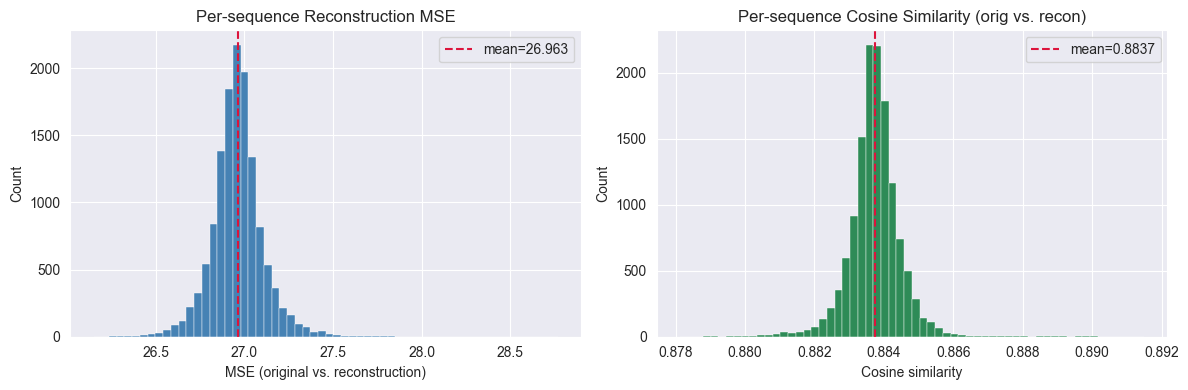

In [73]:
from sklearn.metrics.pairwise import cosine_similarity

orig = layer_24_emb_array
recon = x_hat_np

# Per-sequence MSE
mse_per_seq = np.mean((orig - recon) ** 2, axis=1)

# Per-sequence cosine similarity
cos_sim = np.array([
    cosine_similarity(orig[i:i+1], recon[i:i+1])[0, 0]
    for i in range(len(orig))
])

# Global R² (fraction of variance explained)
ss_res = np.sum((orig - recon) ** 2)
ss_tot = np.sum((orig - orig.mean(axis=0)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"Global R²              : {r2:.4f}")
print(f"Mean MSE per sequence  : {mse_per_seq.mean():.4f} ± {mse_per_seq.std():.4f}")
print(f"Mean cosine similarity : {cos_sim.mean():.4f} ± {cos_sim.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mse_per_seq, bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("MSE (original vs. reconstruction)")
axes[0].set_ylabel("Count")
axes[0].set_title("Per-sequence Reconstruction MSE")
axes[0].axvline(mse_per_seq.mean(), color="crimson", linestyle="--", label=f"mean={mse_per_seq.mean():.3f}")
axes[0].legend()

axes[1].hist(cos_sim, bins=60, color="seagreen", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Cosine similarity")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-sequence Cosine Similarity (orig vs. recon)")
axes[1].axvline(cos_sim.mean(), color="crimson", linestyle="--", label=f"mean={cos_sim.mean():.4f}")
axes[1].legend()

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, "sae_reconstruction_quality.png"), dpi=150)
plt.show()

## 2. Sparsity of the Hidden Layer

For each sequence, how many SAE features are active (L0) and what is the total activation magnitude (L1)?
The histogram of L0 shows how "sparse" the representation is.

SAE dict size           : 10240
Dead features (never active): 10220 (99.8%)
Mean L0 per sequence    : 14.7 ± 0.5
Median L0               : 15
Mean L1 per sequence    : 1.57 ± 0.01


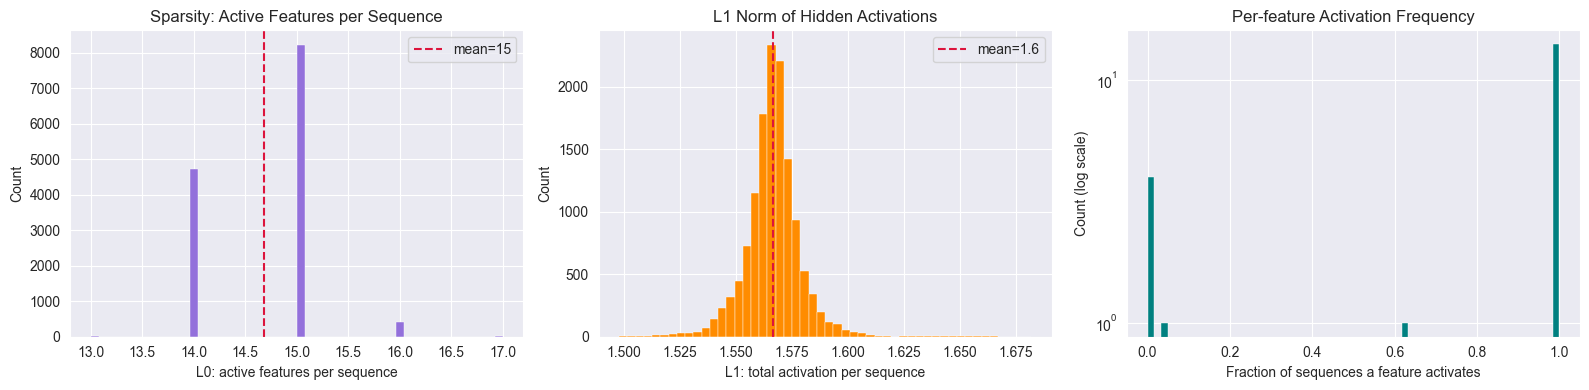

In [74]:
# L0 = number of active (nonzero) features per sequence
l0_per_seq = (features_np > 0).sum(axis=1)
# L1 = sum of activations per sequence
l1_per_seq = features_np.sum(axis=1)
# Fraction of features ever active across all sequences
ever_active = (features_np > 0).any(axis=0)
frac_dead = 1 - ever_active.mean()

# Per-feature activation frequency (how often each feature fires)
feat_freq = (features_np > 0).mean(axis=0)
mean_act_when_on = np.where(feat_freq > 0, features_np.mean(axis=0) / np.where(feat_freq > 0, feat_freq, 1), 0)

print(f"SAE dict size           : {sae.dict_size}")
print(f"Dead features (never active): {(~ever_active).sum()} ({frac_dead*100:.1f}%)")
print(f"Mean L0 per sequence    : {l0_per_seq.mean():.1f} ± {l0_per_seq.std():.1f}")
print(f"Median L0               : {np.median(l0_per_seq):.0f}")
print(f"Mean L1 per sequence    : {l1_per_seq.mean():.2f} ± {l1_per_seq.std():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# L0 histogram
axes[0].hist(l0_per_seq, bins=50, color="mediumpurple", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("L0: active features per sequence")
axes[0].set_ylabel("Count")
axes[0].set_title("Sparsity: Active Features per Sequence")
axes[0].axvline(l0_per_seq.mean(), color="crimson", linestyle="--", label=f"mean={l0_per_seq.mean():.0f}")
axes[0].legend()

# L1 histogram
axes[1].hist(l1_per_seq, bins=50, color="darkorange", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("L1: total activation per sequence")
axes[1].set_ylabel("Count")
axes[1].set_title("L1 Norm of Hidden Activations")
axes[1].axvline(l1_per_seq.mean(), color="crimson", linestyle="--", label=f"mean={l1_per_seq.mean():.1f}")
axes[1].legend()

# Feature activation frequency (log scale)
axes[2].hist(feat_freq[feat_freq > 0], bins=60, color="teal", edgecolor="white", linewidth=0.3, log=True)
axes[2].set_xlabel("Fraction of sequences a feature activates")
axes[2].set_ylabel("Count (log scale)")
axes[2].set_title("Per-feature Activation Frequency")

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, "sae_sparsity.png"), dpi=150)
plt.show()

## 3. Top Features Heatmap

Pick the top-K most frequently activating features and plot their activations across a random sample of sequences.
This reveals whether features are broadly shared or highly selective.

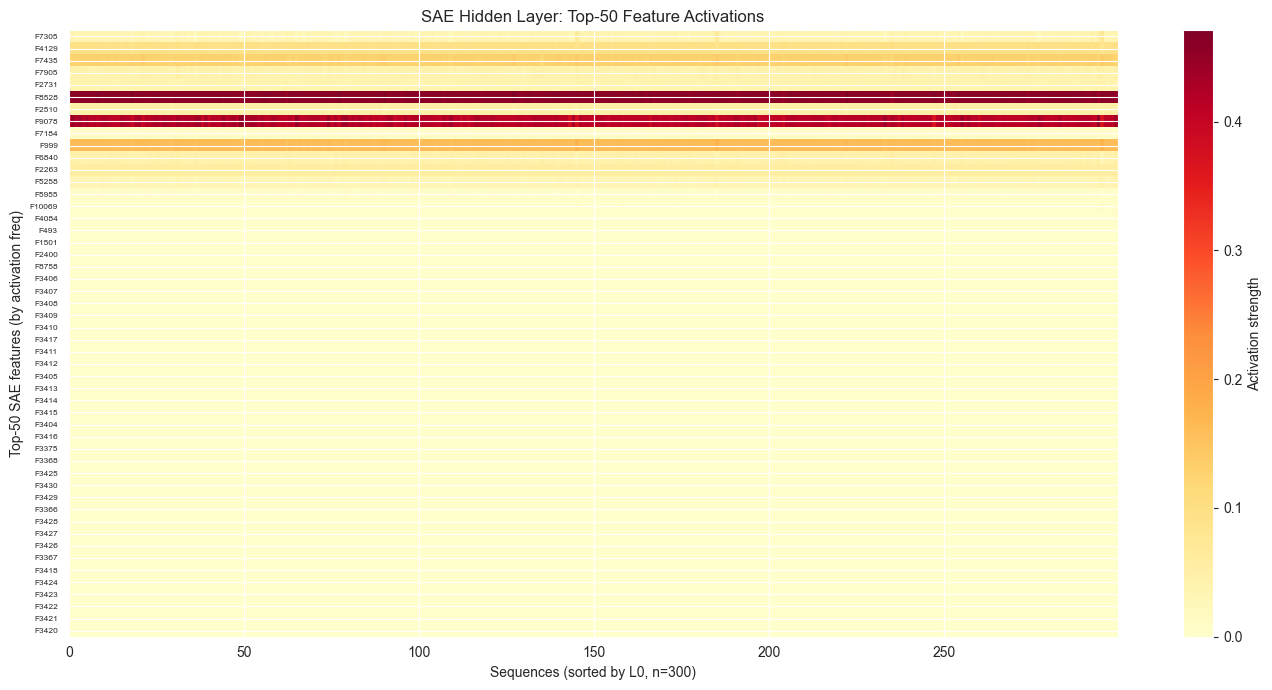

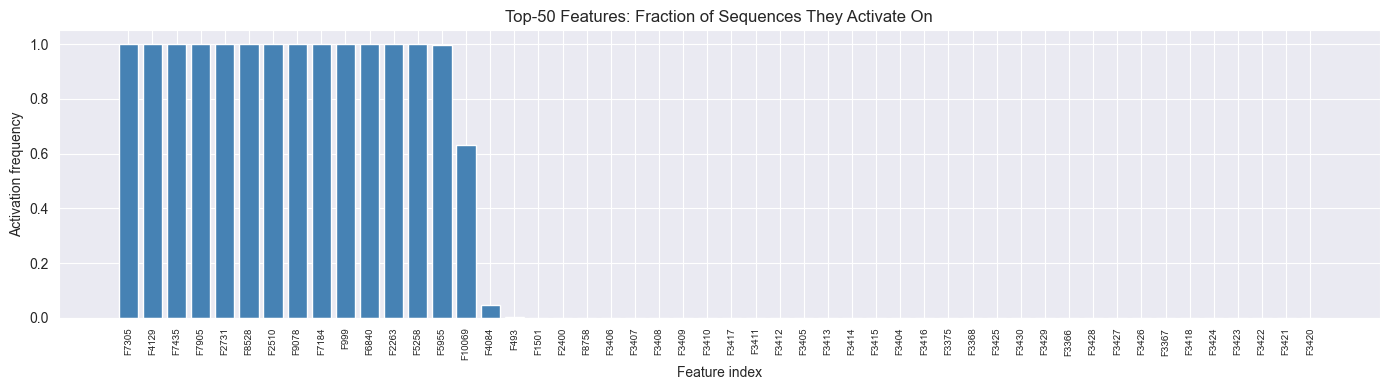

In [75]:
TOP_K = 50
N_SEQS_SAMPLE = 300
rng = np.random.default_rng(42)

# Top-K features by activation frequency
top_feat_idx = np.argsort(feat_freq)[::-1][:TOP_K]

# Random sample of sequences
sample_idx = rng.choice(len(features_np), size=N_SEQS_SAMPLE, replace=False)
sample_idx = sample_idx[np.argsort(l0_per_seq[sample_idx])]  # sort by L0 for nicer display

feat_matrix = features_np[np.ix_(sample_idx, top_feat_idx)]  # (N_SEQS_SAMPLE, TOP_K)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(feat_matrix.T, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_xlabel(f"Sequences (sorted by L0, n={N_SEQS_SAMPLE})")
ax.set_ylabel(f"Top-{TOP_K} SAE features (by activation freq)")
ax.set_title(f"SAE Hidden Layer: Top-{TOP_K} Feature Activations")
ax.set_yticks(range(TOP_K))
ax.set_yticklabels([f"F{i}" for i in top_feat_idx], fontsize=6)
plt.colorbar(im, ax=ax, label="Activation strength")
plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, "sae_top_features_heatmap.png"), dpi=150)
plt.show()

# Bar chart: top-K feature activation frequencies
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(TOP_K), feat_freq[top_feat_idx], color="steelblue")
ax.set_xticks(range(TOP_K))
ax.set_xticklabels([f"F{i}" for i in top_feat_idx], rotation=90, fontsize=7)
ax.set_xlabel("Feature index")
ax.set_ylabel("Activation frequency")
ax.set_title(f"Top-{TOP_K} Features: Fraction of Sequences They Activate On")
plt.tight_layout()
#lt.savefig(os.path.join(OUTPUT_DIR, "sae_top_features_freq.png"), dpi=150)
plt.show()

## 4. PCA of Original, Reconstructed, and SAE Feature Embeddings

PCA lets us compare how much structure is captured in three spaces:
- **Original** ESM2 layer-24 embeddings
- **Reconstructed** embeddings from the SAE decoder
- **SAE features** (the sparse hidden layer itself)

Coloring by L0 (sparsity) shows how sparsity relates to position in embedding space.

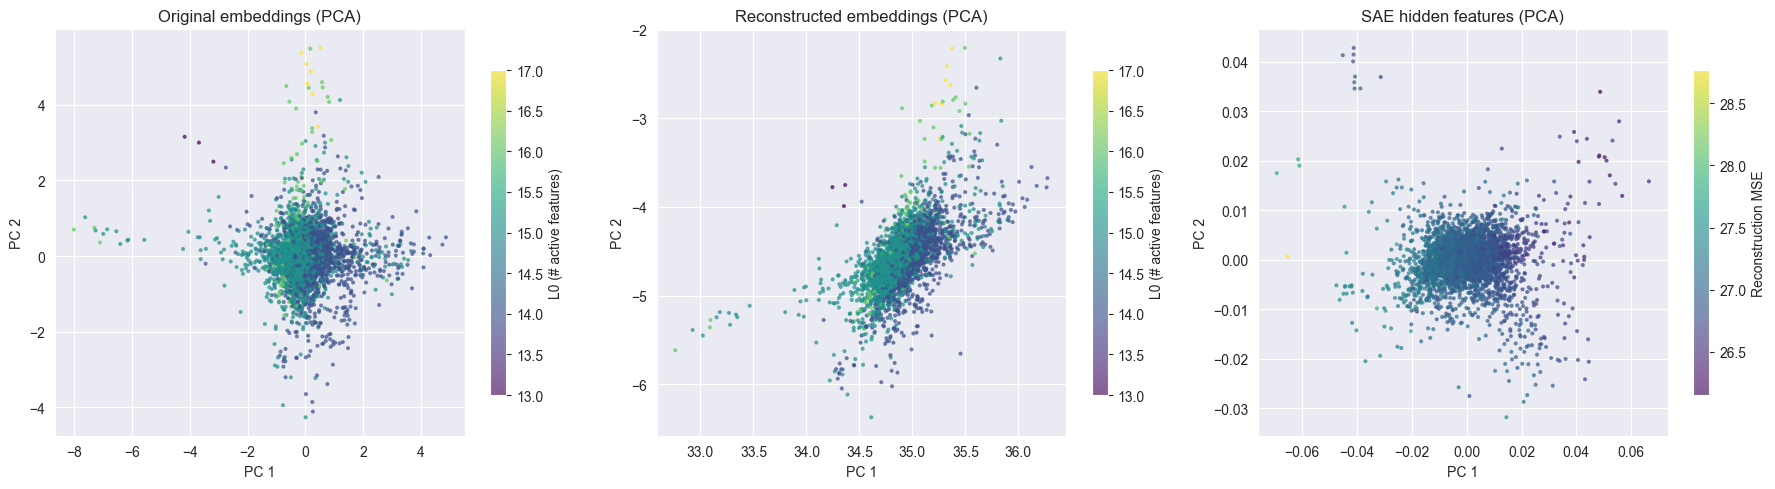

Var explained by top-2 PCs (original embeddings): 38.3%
Var explained by top-2 PCs (SAE features)        : 82.7%


In [76]:
from sklearn.decomposition import PCA

N_PCA = 2

# PCA on a subsample for speed (use all if N < 5000)
N_SUB = min(len(orig), 5000)
sub = rng.choice(len(orig), size=N_SUB, replace=False)

pca_orig  = PCA(n_components=N_PCA).fit(orig[sub])
pca_feat  = PCA(n_components=N_PCA).fit(features_np[sub])

pc_orig  = pca_orig.transform(orig[sub])
pc_recon = pca_orig.transform(recon[sub])   # project recon into original PCA space
pc_feat  = pca_feat.transform(features_np[sub])

l0_sub = l0_per_seq[sub]
mse_sub = mse_per_seq[sub]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, coords, title, cvals, clabel in [
    (axes[0], pc_orig,  "Original embeddings (PCA)",        l0_sub,  "L0 (# active features)"),
    (axes[1], pc_recon, "Reconstructed embeddings (PCA)",   l0_sub,  "L0 (# active features)"),
    (axes[2], pc_feat,  "SAE hidden features (PCA)",        mse_sub, "Reconstruction MSE"),
]:
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=cvals, cmap="viridis", s=4, alpha=0.6, rasterized=True)
    ax.set_title(title)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    plt.colorbar(sc, ax=ax, label=clabel, shrink=0.8)

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, "sae_pca.png"), dpi=150)
plt.show()

print(f"Var explained by top-2 PCs (original embeddings): {pca_orig.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Var explained by top-2 PCs (SAE features)        : {pca_feat.explained_variance_ratio_.sum()*100:.1f}%")

---
## Cross-dataset SAE Feature Comparison

For each available dataset we run the SAE on all layer-24 embeddings (batched to stay memory-safe for large datasets like Ube4b) and compute the **per-feature activation frequency** — the fraction of sequences for which each feature fires.

Features are then classified as:
- **Common** — fires above threshold in *all* available datasets (shared biological signal)
- **Dataset-unique** — fires above threshold in exactly *one* dataset (protein-specific)
- **Partially shared** — fires in 2 to D−1 datasets

In [77]:
from tqdm.auto import tqdm

THRESHOLD  = 0.01    # freq > 1% → feature is "present" in that dataset
CHUNK_SIZE = 1024
TOP_K_HEAT = 60      # features shown in the heatmap
TOP_UNIQUE  = 15     # unique features shown per dataset

# ── 1. Compute per-feature activation frequency for each dataset ───────────────
dataset_feat_freq = {}
dataset_n_seqs    = {}

for dataset in datasets:
    emb_path = os.path.join(ESMDIR, f"data/sequence_data/{dataset}/layer24_seq_to_emb.pkl")
    if not os.path.exists(emb_path):
        print(f"  {dataset}: skipped (no layer24 embeddings found)")
        continue

    emb = pd.read_pickle(emb_path)   # (N, 1280)
    N   = len(emb)

    # Stream through in chunks — avoids storing N × dict_size in memory
    active_count = np.zeros(sae.dict_size, dtype=np.float64)
    for start in tqdm(range(0, N, CHUNK_SIZE), desc=dataset, leave=False):
        chunk = torch.tensor(emb[start : start + CHUNK_SIZE],
                             dtype=torch.float32).to(device)
        with torch.no_grad():
            _, f = sae(chunk, output_features=True)
        active_count += (f.cpu().numpy() > 0).sum(axis=0)

    dataset_feat_freq[dataset] = active_count / N
    dataset_n_seqs[dataset]    = N
    print(f"  {dataset}: {N:>7,} sequences  |  dict_size={sae.dict_size}")

avail = list(dataset_feat_freq.keys())
D     = len(avail)
print(f"\nDatasets with layer-24 embeddings: {avail}")

# ── 2. Frequency matrix and binary presence ────────────────────────────────────
freq_matrix = np.stack([dataset_feat_freq[d] for d in avail])   # (D, dict_size)
present     = freq_matrix > THRESHOLD                            # (D, dict_size)

n_datasets_on       = present.sum(axis=0)                       # (dict_size,)
common_mask         = n_datasets_on == D
unique_masks        = {d: present[i] & (n_datasets_on == 1) for i, d in enumerate(avail)}
partial_mask        = (n_datasets_on > 1) & ~common_mask
inactive_mask       = n_datasets_on == 0

print(f"\nFeature overlap (threshold = {THRESHOLD}):")
print(f"  Common  (all {D} datasets)         : {common_mask.sum():>5}")
print(f"  Partial (2–{D-1} datasets)          : {partial_mask.sum():>5}")
for d in avail:
    print(f"  Unique  to {d:<10}             : {unique_masks[d].sum():>5}")
print(f"  Inactive in all datasets           : {inactive_mask.sum():>5}")

BF520:   0%|          | 0/13 [00:00<?, ?it/s]

  BF520:  13,190 sequences  |  dict_size=10240


BG505:   0%|          | 0/14 [00:00<?, ?it/s]

  BG505:  13,386 sequences  |  dict_size=10240

Datasets with layer-24 embeddings: ['BF520', 'BG505']

Feature overlap (threshold = 0.01):
  Common  (all 2 datasets)         :    15
  Partial (2–1 datasets)          :     0
  Unique  to BF520                  :     0
  Unique  to BG505                  :     1
  Inactive in all datasets           : 10224


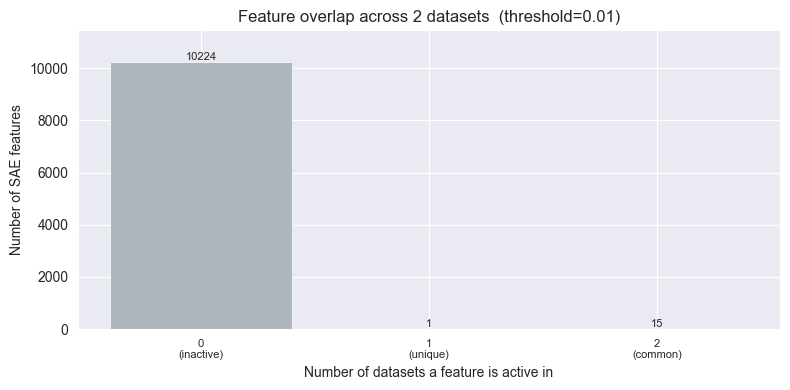

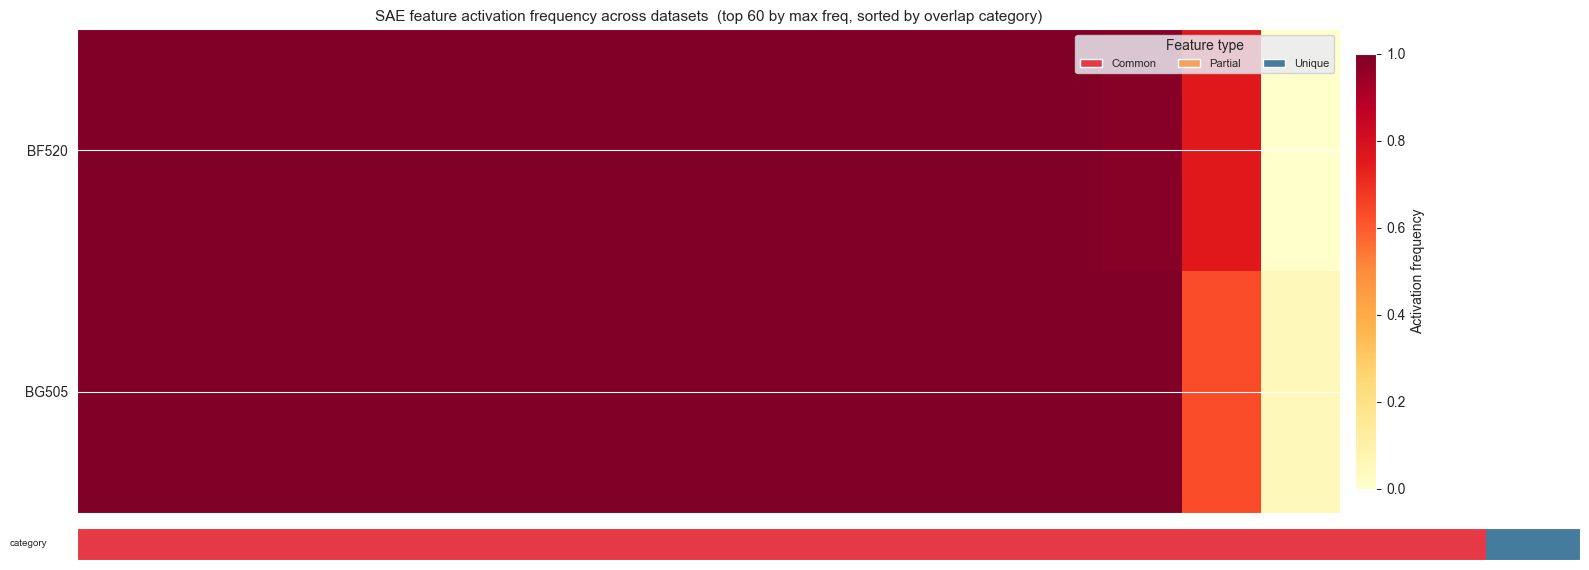

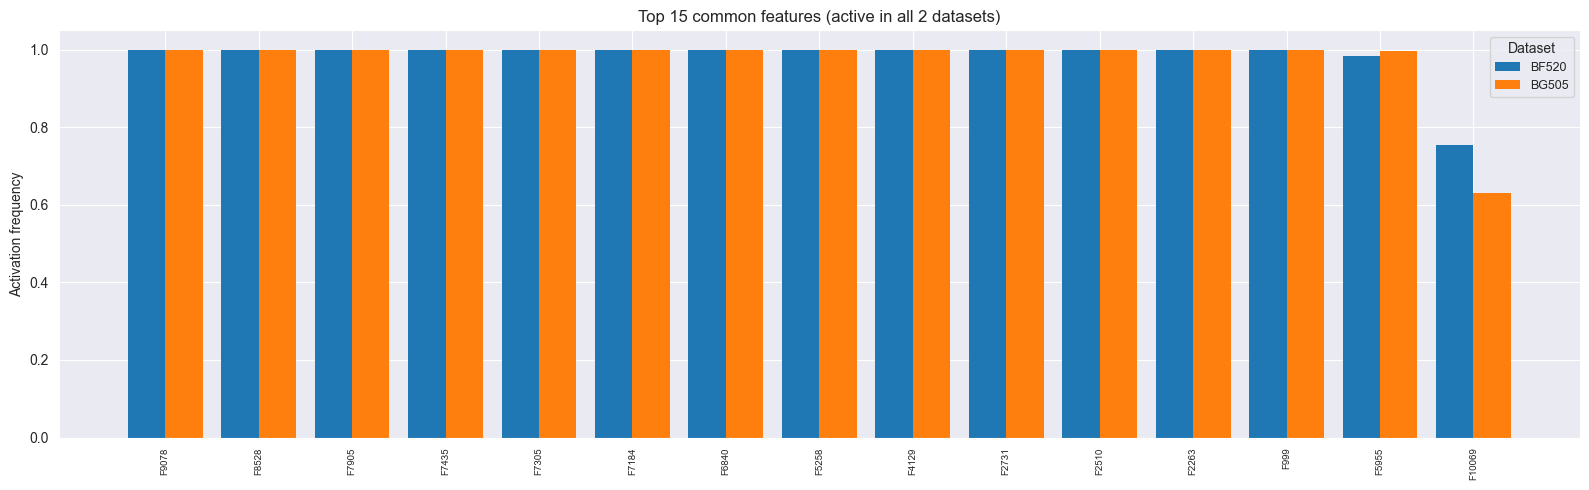

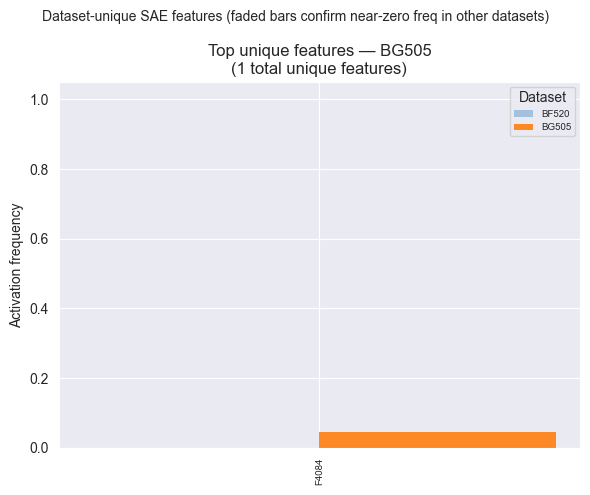

In [78]:
import math

# ── 3. Visualisations ──────────────────────────────────────────────────────────

# Colour palette: one colour per dataset, plus colours for feature categories
ds_colors   = dict(zip(avail, plt.cm.tab10.colors[:D]))
cat_colors  = {"common": "#e63946", "partial": "#f4a261", "unique": "#457b9d", "inactive": "#adb5bd"}

# Category label for each feature
feat_category = np.where(
    common_mask,  "common",
    np.where(inactive_mask, "inactive",
    np.where(partial_mask,  "partial",  "unique"))
)

# ── Fig 1: Overlap bar chart (UpSet-style summary) ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
counts = [(n_datasets_on == k).sum() for k in range(D + 1)]
bar_colors = [cat_colors["inactive"]] + \
             [cat_colors["unique"]] + \
             [cat_colors["partial"]] * (D - 2) + \
             [cat_colors["common"]]
bars = ax.bar(range(D + 1), counts, color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(D + 1))
ax.set_xticklabels(
    ["0\n(inactive)", "1\n(unique)"] +
    [f"{k}\n(partial)" for k in range(2, D)] +
    [f"{D}\n(common)"],
    fontsize=8,
)
ax.set_xlabel("Number of datasets a feature is active in")
ax.set_ylabel("Number of SAE features")
ax.set_title(f"Feature overlap across {D} datasets  (threshold={THRESHOLD})")
for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(count), ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, max(counts) * 1.12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sae_cross_dataset_overlap.png"), dpi=150)
plt.show()

# ── Fig 2: Cross-dataset heatmap of top features ──────────────────────────────
max_freq        = freq_matrix.max(axis=0)
top_feat_by_max = np.argsort(max_freq)[::-1]
top_feat_by_max = top_feat_by_max[~inactive_mask[top_feat_by_max]][:TOP_K_HEAT]

sort_key   = feat_category[top_feat_by_max]
order_map  = {"common": 0, "partial": 1, "unique": 2, "inactive": 3}
sort_order = np.argsort([order_map[c] for c in sort_key], kind="stable")
top_feat_sorted = top_feat_by_max[sort_order]
cats_sorted     = feat_category[top_feat_sorted]

heat_data = freq_matrix[:, top_feat_sorted]   # (D, TOP_K_HEAT)

fig, (ax_heat, ax_strip) = plt.subplots(
    2, 1, figsize=(16, 5 + D * 0.4),
    gridspec_kw={"height_ratios": [6, 0.4]},
    sharex=True,
)
im = ax_heat.imshow(heat_data, aspect="auto", cmap="YlOrRd",
                    vmin=0, vmax=min(heat_data.max(), 1.0))
ax_heat.set_yticks(range(D))
ax_heat.set_yticklabels(avail, fontsize=10)
ax_heat.set_title(
    f"SAE feature activation frequency across datasets  "
    f"(top {TOP_K_HEAT} by max freq, sorted by overlap category)",
    fontsize=11,
)
plt.colorbar(im, ax=ax_heat, label="Activation frequency", pad=0.01, shrink=0.9)

ax_heat.set_xticks(range(len(top_feat_sorted)))
xlabels = ax_heat.set_xticklabels(
    [f"F{i}" for i in top_feat_sorted], rotation=90, fontsize=5.5
)
for lbl, cat in zip(xlabels, cats_sorted):
    lbl.set_color(cat_colors[cat])

import matplotlib.colors as mcolors
strip_rgb = np.array([[mcolors.to_rgb(cat_colors[c]) for c in cats_sorted]])
ax_strip.imshow(strip_rgb, aspect="auto")
ax_strip.set_yticks([])
ax_strip.set_xticks([])
ax_strip.set_ylabel("category", fontsize=7, rotation=0, labelpad=35, va="center")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cat_colors[c], label=c.capitalize())
                   for c in ["common", "partial", "unique"]]
ax_heat.legend(handles=legend_elements, loc="upper right", fontsize=8,
               title="Feature type", framealpha=0.85, ncol=3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sae_cross_dataset_heatmap.png"), dpi=150)
plt.show()

# ── Fig 3: Common features — top by mean freq across datasets ─────────────────
if common_mask.sum() > 0:
    common_idx       = np.where(common_mask)[0]
    mean_freq_common = freq_matrix[:, common_idx].mean(axis=0)
    top_common       = common_idx[np.argsort(mean_freq_common)[::-1][:30]]
    top_common_freq  = freq_matrix[:, top_common]

    x     = np.arange(len(top_common))
    width = 0.8 / D
    fig, ax = plt.subplots(figsize=(16, 5))
    for i, d in enumerate(avail):
        ax.bar(x + i * width, top_common_freq[i], width=width,
               label=d, color=ds_colors[d], edgecolor="none")
    ax.set_xticks(x + width * (D - 1) / 2)
    ax.set_xticklabels([f"F{i}" for i in top_common], rotation=90, fontsize=7)
    ax.set_ylabel("Activation frequency")
    ax.set_title(f"Top {len(top_common)} common features (active in all {D} datasets)")
    ax.legend(title="Dataset", fontsize=9)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "sae_common_features.png"), dpi=150)
    plt.show()
else:
    print("No common features above threshold — try lowering THRESHOLD.")

# ── Fig 4: Dataset-unique features (grid layout, scales to any number of datasets)
datasets_with_unique = [d for d in avail if unique_masks[d].sum() > 0]
n_panels = len(datasets_with_unique)

if n_panels > 0:
    ncols = min(n_panels, 4)
    nrows = math.ceil(n_panels / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 5 * nrows),
                             squeeze=False)
    # Hide unused axes in the last row
    for idx in range(n_panels, nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    for panel_idx, d in enumerate(datasets_with_unique):
        ax  = axes[panel_idx // ncols, panel_idx % ncols]
        di  = avail.index(d)
        u_idx  = np.where(unique_masks[d])[0]
        u_freq = freq_matrix[di, u_idx]
        top_u  = u_idx[np.argsort(u_freq)[::-1][:TOP_UNIQUE]]
        bar_data = freq_matrix[:, top_u]   # (D, TOP_UNIQUE)
        x = np.arange(len(top_u))
        w = 0.8 / D
        for j, dd in enumerate(avail):
            ax.bar(x + j * w, bar_data[j], width=w, label=dd,
                   color=ds_colors[dd], alpha=0.9 if dd == d else 0.35,
                   edgecolor="none")
        ax.set_xticks(x + w * (D - 1) / 2)
        ax.set_xticklabels([f"F{i}" for i in top_u], rotation=90, fontsize=7)
        ax.set_ylabel("Activation frequency")
        ax.set_title(f"Top unique features — {d}\n({unique_masks[d].sum()} total unique features)")
        ax.legend(title="Dataset", fontsize=7, loc="upper right")
        ax.set_ylim(0, 1.05)

    plt.suptitle("Dataset-unique SAE features (faded bars confirm near-zero freq in other datasets)",
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "sae_unique_features.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No dataset-unique features above threshold.")

# Sparse Principal Component Analysis on Layer N (N=24) Embeddings

As the embedding dimensions are highly-correlated and our model assumes independent features, we want to try and create a sparse representation of the original embedding space. Above is an SAE analysis, next we will try a sparse PCA approach. We will compare the SAE and SPCA features to see the differences in sparsity, performance, and interpretability.

In [83]:
from sklearn.decomposition import MiniBatchSparsePCA, PCA
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
import time, math

# ── Config ────────────────────────────────────────────────────────────────────
SPCA_DATASET    = "BRCA1"   # dataset to analyse (must have layer24_seq_to_emb.pkl)
N_COMPONENTS    = 10
ALPHA           = 5.0       # L1 penalty — raise for sparser components
SPCA_OUTPUT_DIR = ESMDIR + "/plots/"

# ── Load embeddings ───────────────────────────────────────────────────────────
emb_path = os.path.join(ESMDIR, f"data/sequence_data/{SPCA_DATASET}/layer24_seq_to_emb.pkl")
if not os.path.exists(emb_path):
    raise FileNotFoundError(
        f"{SPCA_DATASET} has no layer24 embeddings at {emb_path}. "
        f"Change SPCA_DATASET to one of: BRCA1, TpoR, Ube4b"
    )

X = pd.read_pickle(emb_path)                   # (N, 1280)
X_meta = pd.read_pickle(os.path.join(
    ESMDIR, f"data/sequence_data/{SPCA_DATASET}/inference_metadata.pkl"
))
print(f"Dataset: {SPCA_DATASET}  |  sequences: {X.shape[0]:,}  |  embedding dim: {X.shape[1]}")

Dataset: BRCA1  |  sequences: 12,264  |  embedding dim: 1280


In [84]:
# ── Fit regular PCA and Sparse PCA ───────────────────────────────────────────
pca_s    = PCA(n_components=N_COMPONENTS, random_state=42)
sc_pca   = pca_s.fit_transform(X)          # (N, K)
ev_ratio = pca_s.explained_variance_ratio_ # (K,)
pca_comps_s = pca_s.components_            # (K, 1280)

print(f"Fitting Sparse PCA  (n_components={N_COMPONENTS}, α={ALPHA}) …")
t0 = time.time()
spca_s = MiniBatchSparsePCA(
    n_components=N_COMPONENTS,
    alpha=ALPHA,
    max_iter=100,
    batch_size=200,
    random_state=42,
    n_jobs=-1,
)
sc_spca      = spca_s.fit_transform(X)     # (N, K)
spca_comps_s = spca_s.components_          # (K, 1280)
print(f"  done in {time.time()-t0:.1f}s")

# ── Sparsity stats ────────────────────────────────────────────────────────────
n_nz      = (spca_comps_s != 0).sum(axis=1)   # non-zero loadings per component
sparsity_s = (1 - n_nz / spca_comps_s.shape[1]) * 100

# R² of sparse reconstruction
X_c   = X - X.mean(axis=0)
X_hat = sc_spca @ spca_comps_s
r2    = 1 - np.sum((X_c - X_hat)**2) / np.sum(X_c**2)

print(f"\nPCA  var explained (top {N_COMPONENTS}) : {ev_ratio.sum()*100:.1f}%")
print(f"SparsePCA R²   (all {N_COMPONENTS} comps): {r2*100:.1f}%")
print(f"Mean component sparsity                  : {sparsity_s.mean():.1f}% ± {sparsity_s.std():.1f}%")
print(f"Non-zero dims per component              : {n_nz.tolist()}")

# ── Per-sequence metadata aligned to X rows (seq_id = row index) ──────────────
seq_meta_s = (
    X_meta.groupby("seq_id")
    .agg(mean_freq=("Frequency", "mean"), mean_gen=("Generation", "mean"))
    .reset_index()
)
valid_s     = seq_meta_s["seq_id"].values[seq_meta_s["seq_id"].values < len(X)]
freq_s      = seq_meta_s.set_index("seq_id").loc[valid_s, "mean_freq"].values
gen_s       = seq_meta_s.set_index("seq_id").loc[valid_s, "mean_gen"].values
sc_spca_aligned = sc_spca[valid_s]
sc_pca_aligned  = sc_pca[valid_s]

Fitting Sparse PCA  (n_components=10, α=5.0) …
  done in 14.5s

PCA  var explained (top 10) : 75.7%
SparsePCA R²   (all 10 comps): 43.9%
Mean component sparsity                  : 86.2% ± 3.4%
Non-zero dims per component              : [253, 208, 123, 148, 103, 174, 183, 160, 213, 207]


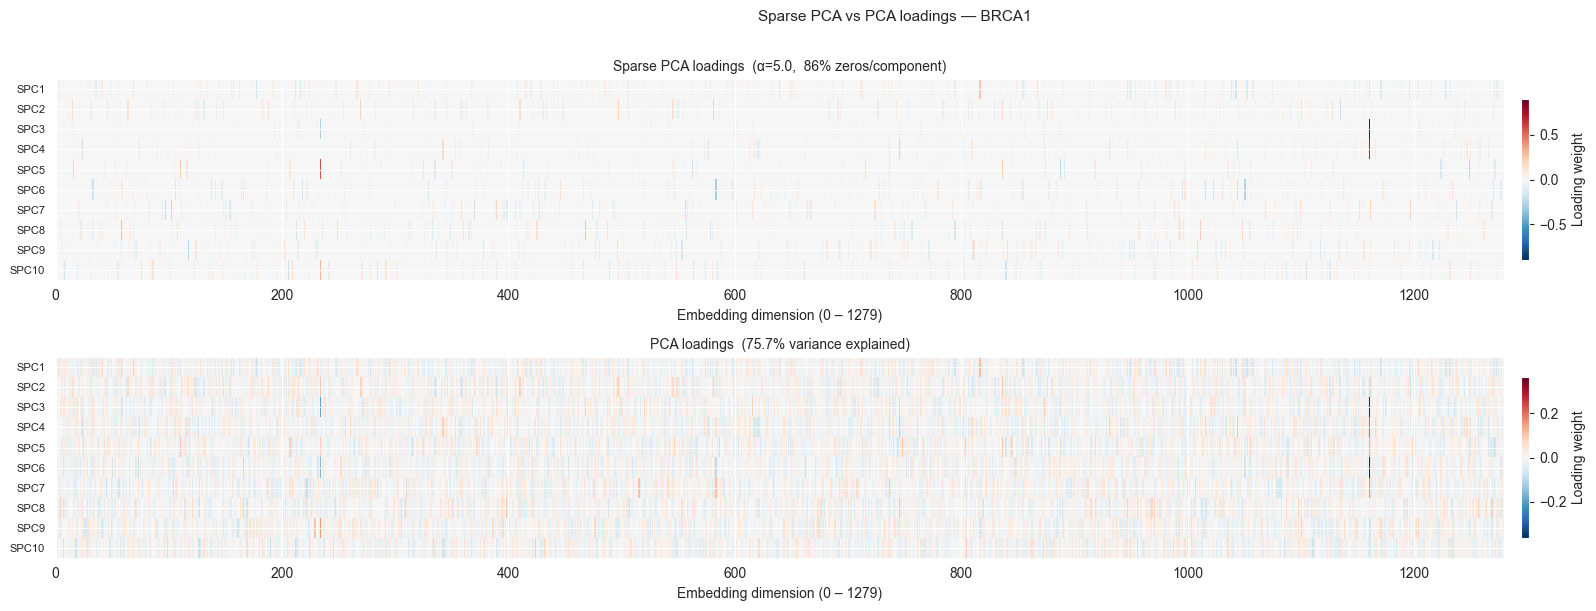

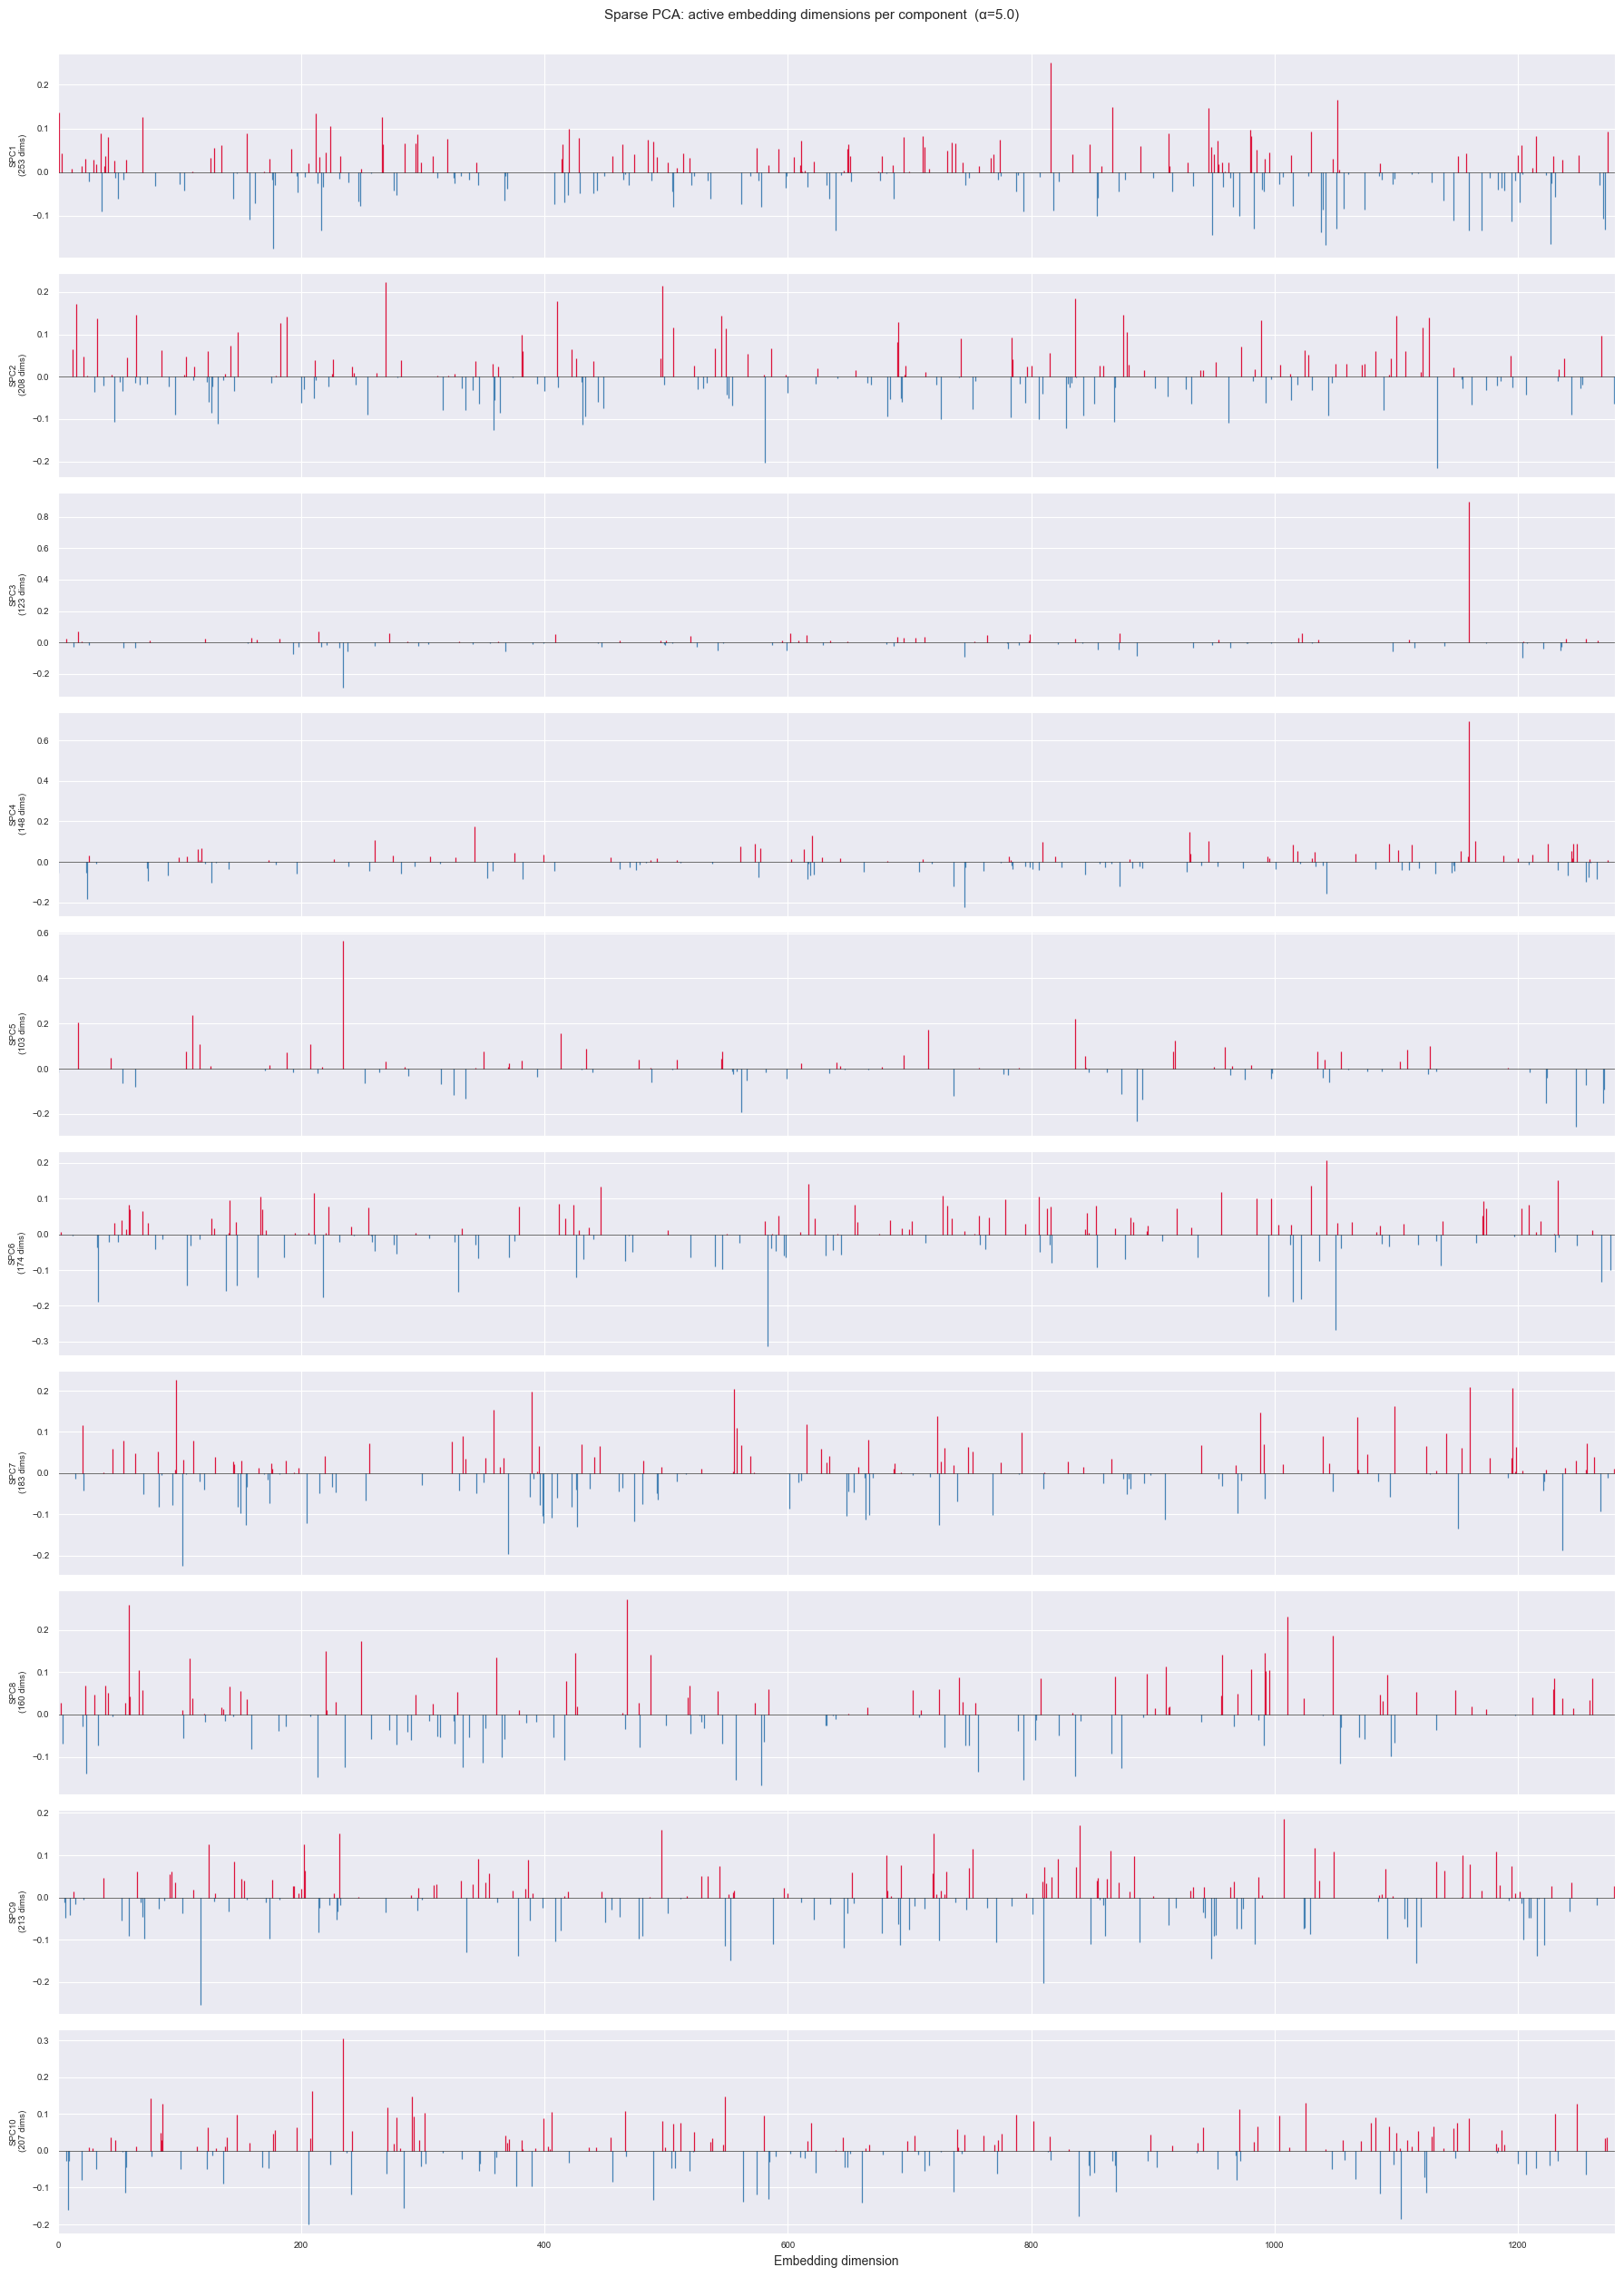

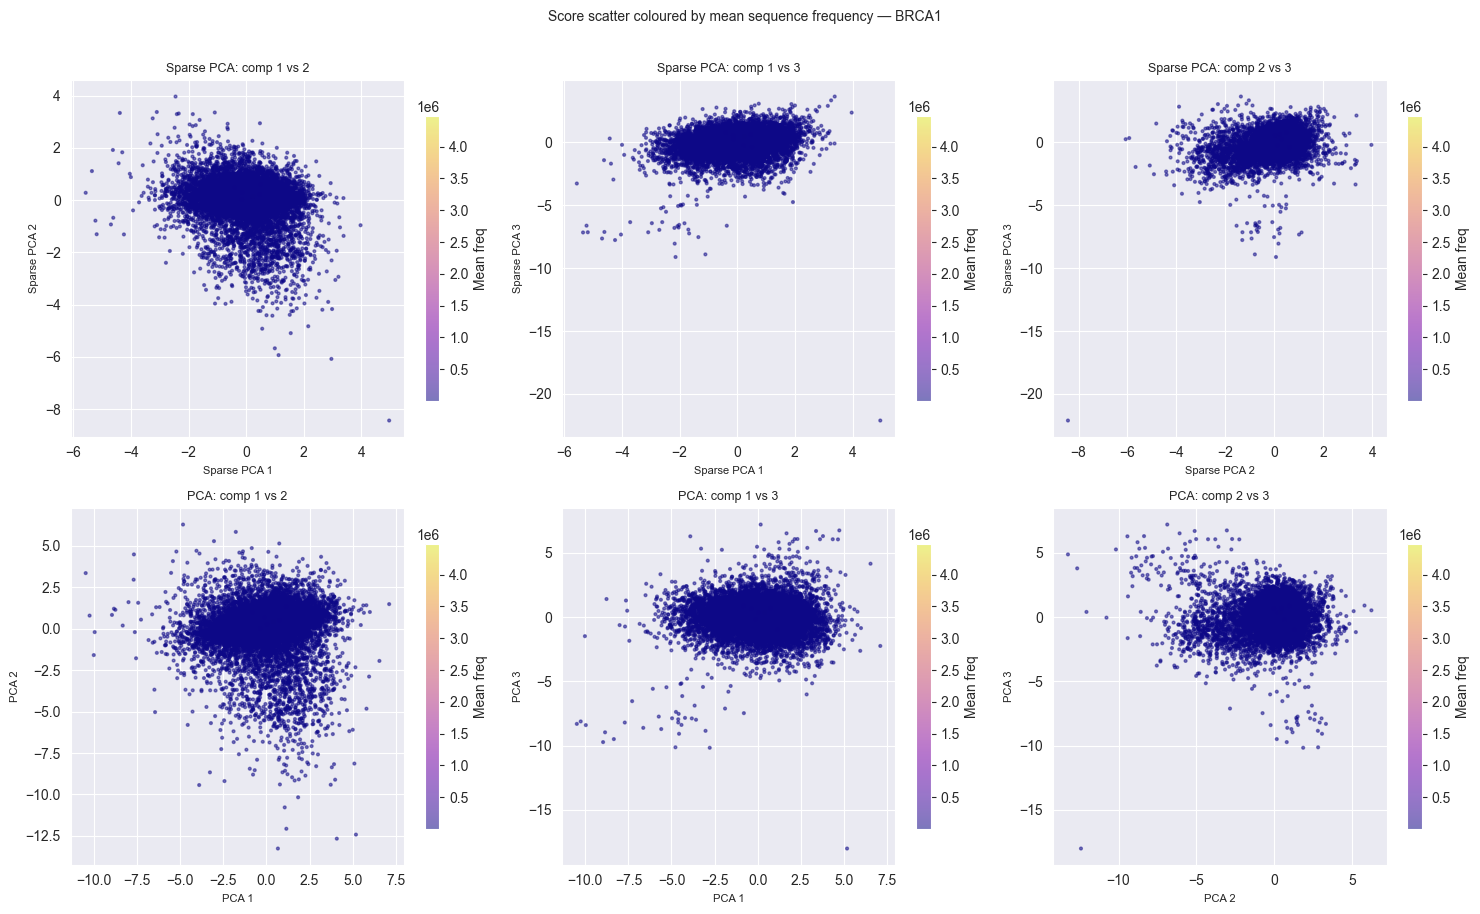

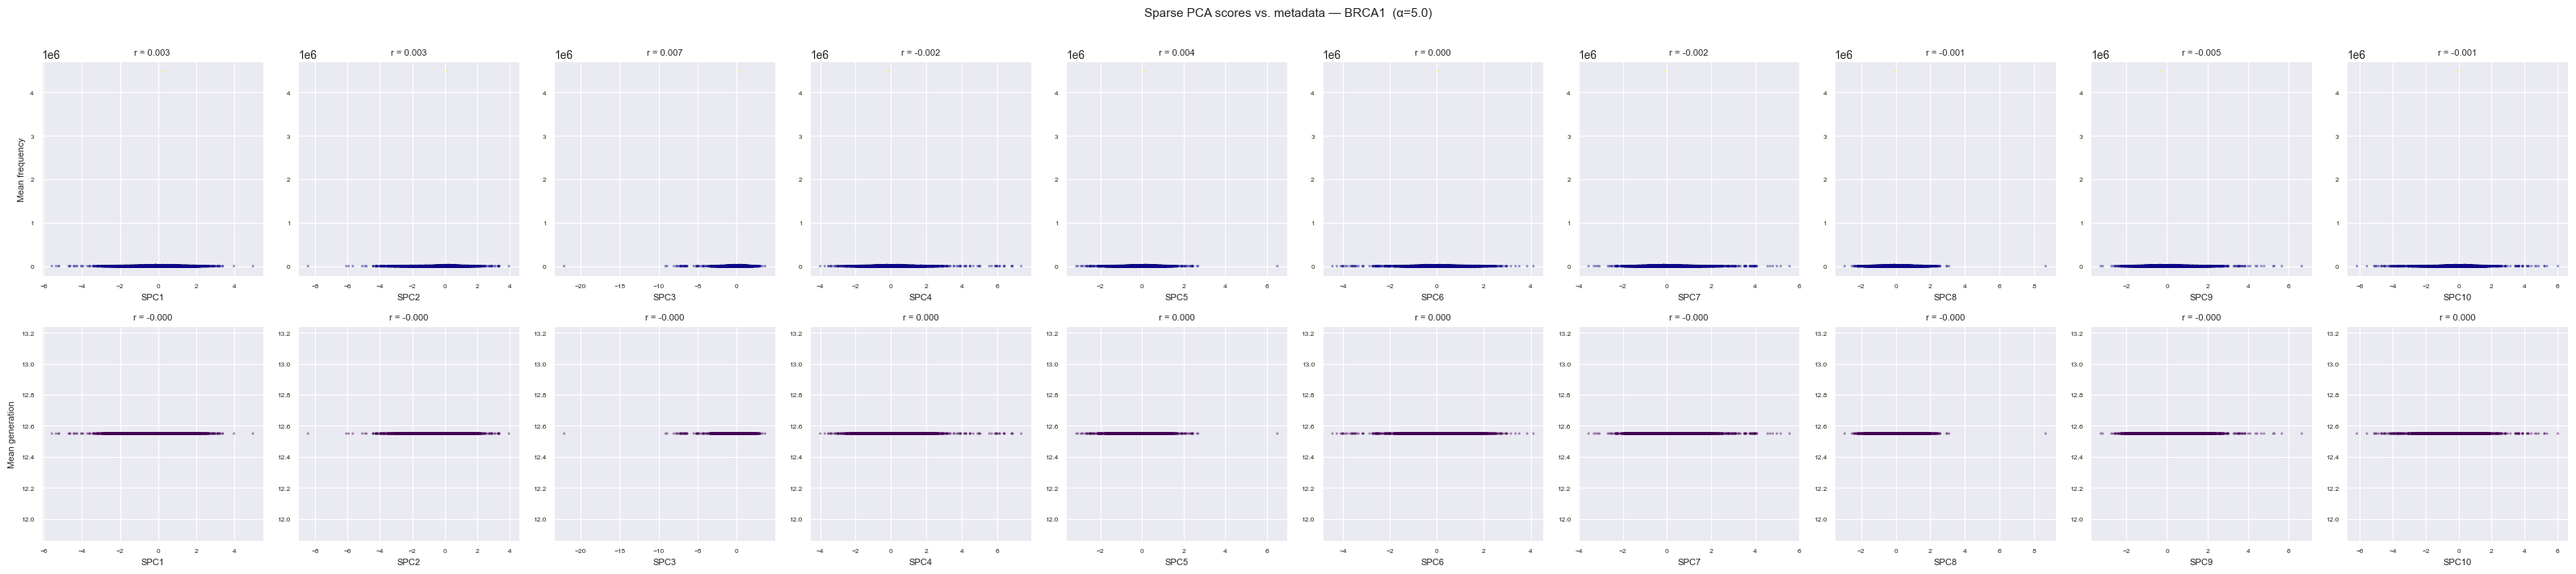

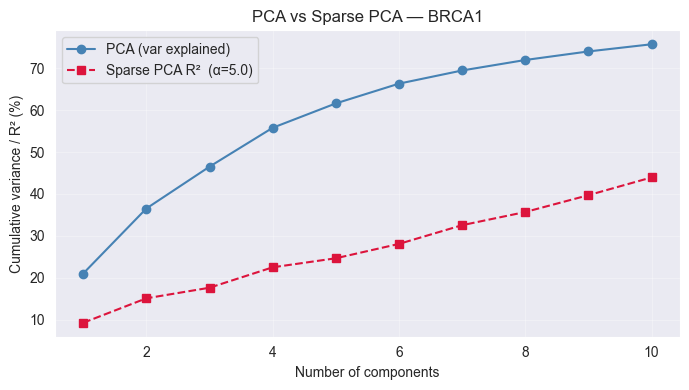

In [85]:
comp_labels_s = [f"SPC{i+1}" for i in range(N_COMPONENTS)]

# ── Fig 1: Loading heatmaps — Sparse PCA (top) vs PCA (bottom) ───────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 6))
for ax, comps, title in [
    (axes[0], spca_comps_s,
     f"Sparse PCA loadings  (α={ALPHA},  {sparsity_s.mean():.0f}% zeros/component)"),
    (axes[1], pca_comps_s,
     f"PCA loadings  ({ev_ratio.sum()*100:.1f}% variance explained)"),
]:
    vmax = np.abs(comps).max()
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(comps, aspect="auto", cmap="RdBu_r", norm=norm, interpolation="nearest")
    ax.set_yticks(range(N_COMPONENTS))
    ax.set_yticklabels(comp_labels_s, fontsize=8)
    ax.set_xlabel("Embedding dimension (0 – 1279)")
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, label="Loading weight", shrink=0.8, pad=0.01)
plt.suptitle(f"Sparse PCA vs PCA loadings — {SPCA_DATASET}", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_loadings_heatmap.png"), dpi=150)
plt.show()

# ── Fig 2: Active-dimension stem plots (one per sparse component) ─────────────
fig, axes = plt.subplots(N_COMPONENTS, 1, figsize=(18, 2.5 * N_COMPONENTS), sharex=True)
for i, ax in enumerate(axes):
    vals    = spca_comps_s[i]
    nz_idx  = np.where(vals != 0)[0]
    ax.vlines(nz_idx, 0, vals[nz_idx], linewidth=0.9,
              colors=["crimson" if v > 0 else "steelblue" for v in vals[nz_idx]])
    ax.axhline(0, color="black", linewidth=0.4)
    ax.set_ylabel(f"{comp_labels_s[i]}\n({len(nz_idx)} dims)", fontsize=7)
    ax.set_xlim(0, spca_comps_s.shape[1])
    ax.tick_params(labelsize=7)
axes[-1].set_xlabel("Embedding dimension")
fig.suptitle(f"Sparse PCA: active embedding dimensions per component  (α={ALPHA})", fontsize=11, y=1.002)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_active_dims.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Fig 3: Score scatter — Sparse PCA vs PCA, coloured by mean frequency ─────
pairs = [(0, 1), (0, 2), (1, 2)]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for col, (i, j) in enumerate(pairs):
    for row, (scores, method) in enumerate([
        (sc_spca_aligned, "Sparse PCA"),
        (sc_pca_aligned,  "PCA"),
    ]):
        ax = axes[row, col]
        sc = ax.scatter(scores[:, i], scores[:, j],
                        c=freq_s, cmap="plasma", s=4, alpha=0.5, rasterized=True)
        ax.set_xlabel(f"{method} {i+1}", fontsize=8)
        ax.set_ylabel(f"{method} {j+1}", fontsize=8)
        ax.set_title(f"{method}: comp {i+1} vs {j+1}", fontsize=9)
        plt.colorbar(sc, ax=ax, label="Mean freq", shrink=0.8)
plt.suptitle(f"Score scatter coloured by mean sequence frequency — {SPCA_DATASET}",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_score_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Fig 4: Component score vs metadata (Pearson r grid) ──────────────────────
fig, axes = plt.subplots(2, N_COMPONENTS, figsize=(3.2 * N_COMPONENTS, 7), squeeze=False)
for i in range(N_COMPONENTS):
    for row, (meta, label, cmap) in enumerate([
        (freq_s, "Mean frequency", "plasma"),
        (gen_s,  "Mean generation", "viridis"),
    ]):
        ax = axes[row, i]
        ax.scatter(sc_spca_aligned[:, i], meta,
                   c=meta, cmap=cmap, s=2, alpha=0.3, rasterized=True)
        r = np.corrcoef(sc_spca_aligned[:, i], meta)[0, 1]
        ax.set_xlabel(f"SPC{i+1}", fontsize=8)
        if i == 0:
            ax.set_ylabel(label, fontsize=8)
        ax.set_title(f"r = {r:.3f}", fontsize=8)
        ax.tick_params(labelsize=6)
fig.suptitle(f"Sparse PCA scores vs. metadata — {SPCA_DATASET}  (α={ALPHA})", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_scores_vs_metadata.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Fig 5: Cumulative variance explained — PCA vs sparse PCA ─────────────────
# Compute per-component R² for sparse PCA by sequential projection
r2_per_comp_spca = []
r2_per_comp_pca  = []
ss_tot = np.sum((X - X.mean(axis=0))**2)
for k in range(1, N_COMPONENTS + 1):
    # Sparse PCA: use first k components
    Xh = sc_spca[:, :k] @ spca_comps_s[:k]
    r2_per_comp_spca.append(1 - np.sum((X_c - Xh)**2) / ss_tot)
    # Regular PCA
    r2_per_comp_pca.append(ev_ratio[:k].sum())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, N_COMPONENTS + 1), np.array(r2_per_comp_pca)  * 100,
        "o-", color="steelblue", label="PCA (var explained)")
ax.plot(range(1, N_COMPONENTS + 1), np.array(r2_per_comp_spca) * 100,
        "s--", color="crimson", label=f"Sparse PCA R²  (α={ALPHA})")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative variance / R² (%)")
ax.set_title(f"PCA vs Sparse PCA — {SPCA_DATASET}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_variance_explained.png"), dpi=150)
plt.show()

### Sparse PCA Stability Analysis

Two complementary views of stability:

1. **Bootstrap stability** — fit Sparse PCA on `N_BOOTSTRAP` random 80% subsamples of sequences, then measure how consistently each component is recovered (via absolute cosine similarity after optimal Hungarian matching across runs). High similarity → the component is a reliable feature of the data; low similarity → it varies with the sample and should not be over-interpreted.

2. **Alpha sensitivity** — sweep the sparsity penalty `α` and track how sparsity (% zero loadings) and reconstruction R² trade off. Reveals the regime where components are both sparse *and* informative.

In [89]:
from scipy.optimize import linear_sum_assignment
from tqdm.auto import tqdm

N_BOOTSTRAP = 20
BOOT_FRAC   = 0.8
rng_boot    = np.random.default_rng(0)

ref_comps = spca_comps_s.copy()               # (K, 1280) reference components
ref_norms = np.linalg.norm(ref_comps, axis=1, keepdims=True) + 1e-12

# Accumulate matched cosine similarities (N_BOOTSTRAP, K) and loading vectors
boot_cos  = np.zeros((N_BOOTSTRAP, N_COMPONENTS))
boot_load = np.zeros((N_BOOTSTRAP, N_COMPONENTS, X.shape[1]))

for b in tqdm(range(N_BOOTSTRAP), desc="Bootstrap runs"):
    idx    = rng_boot.choice(len(X), size=int(len(X) * BOOT_FRAC), replace=True)
    spca_b = MiniBatchSparsePCA(
        n_components=N_COMPONENTS, alpha=ALPHA,
        max_iter=50, batch_size=200, random_state=b, n_jobs=-1,
    )
    spca_b.fit(X[idx])
    bc     = spca_b.components_                    # (K, 1280)
    bc_norms = np.linalg.norm(bc, axis=1, keepdims=True) + 1e-12

    # |cosine similarity| matrix: rows = reference, cols = bootstrap
    cos_mat = np.abs((ref_comps @ bc.T) / (ref_norms * bc_norms.T))
    # Optimal assignment: maximise total similarity
    row_idx, col_idx = linear_sum_assignment(-cos_mat)

    for i, j in zip(row_idx, col_idx):
        boot_cos[b, i] = cos_mat[i, j]
        sign = np.sign(ref_comps[i] @ bc[j])      # correct sign flip
        boot_load[b, i] = sign * bc[j]

mean_stab = boot_cos.mean(axis=0)                 # (K,) mean |cos sim| per component
std_stab  = boot_cos.std(axis=0)

print("Bootstrap stability (mean ± std |cos sim| per component):")
for k in range(N_COMPONENTS):
    bar = "█" * int(mean_stab[k] * 20)
    print(f"  SPC{k+1:2d}: {mean_stab[k]:.3f} ± {std_stab[k]:.3f}  {bar}")

Bootstrap runs:   0%|          | 0/20 [00:00<?, ?it/s]

Bootstrap stability (mean ± std |cos sim| per component):
  SPC 1: 0.803 ± 0.125  ████████████████
  SPC 2: 0.750 ± 0.098  ███████████████
  SPC 3: 0.901 ± 0.051  ██████████████████
  SPC 4: 0.552 ± 0.195  ███████████
  SPC 5: 0.442 ± 0.142  ████████
  SPC 6: 0.640 ± 0.153  ████████████
  SPC 7: 0.596 ± 0.156  ███████████
  SPC 8: 0.259 ± 0.250  █████
  SPC 9: 0.540 ± 0.176  ██████████
  SPC10: 0.512 ± 0.185  ██████████


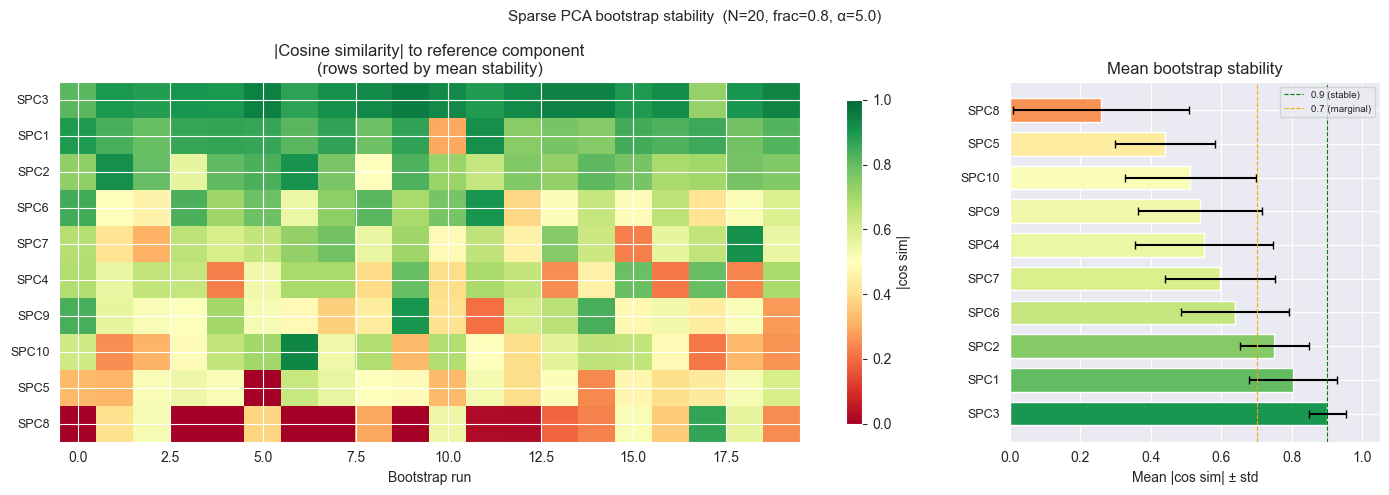

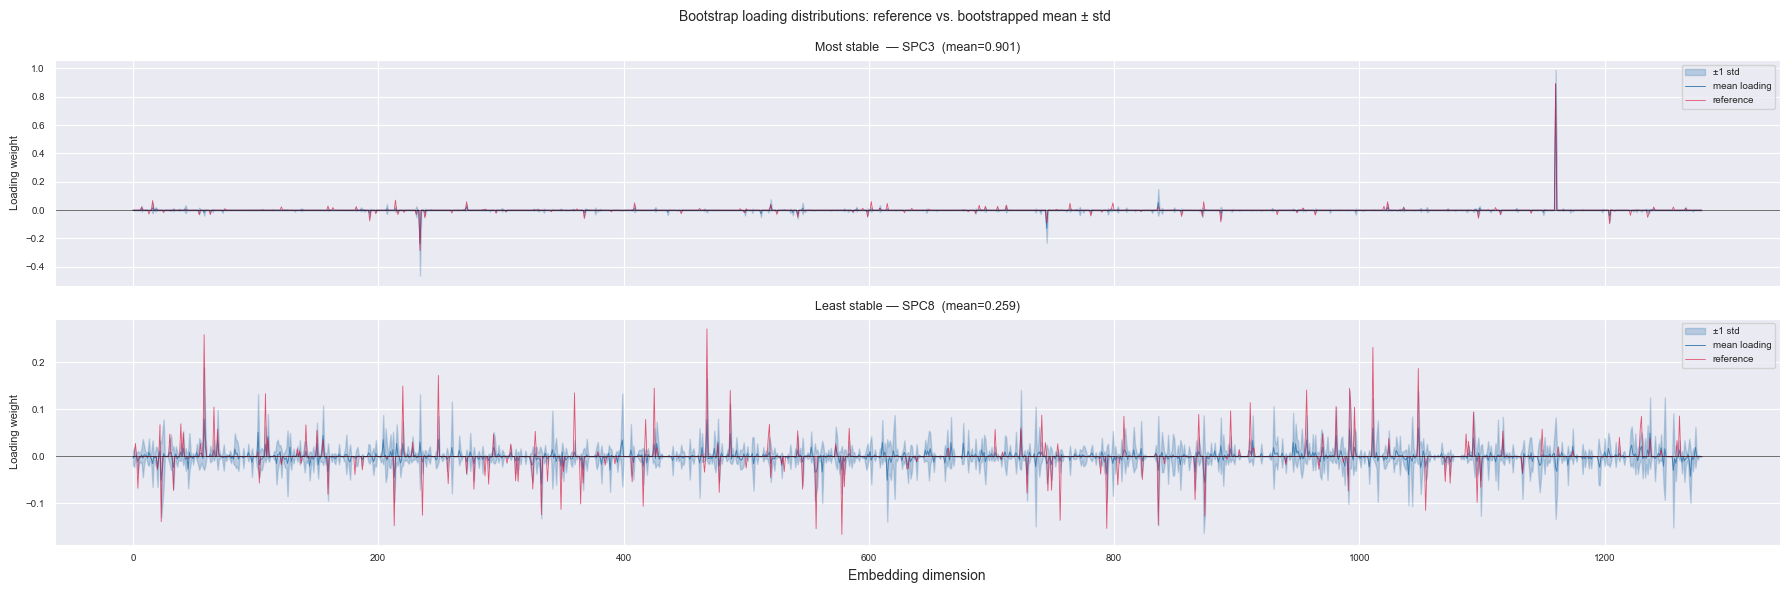

Alpha sweep:   0%|          | 0/7 [00:00<?, ?it/s]

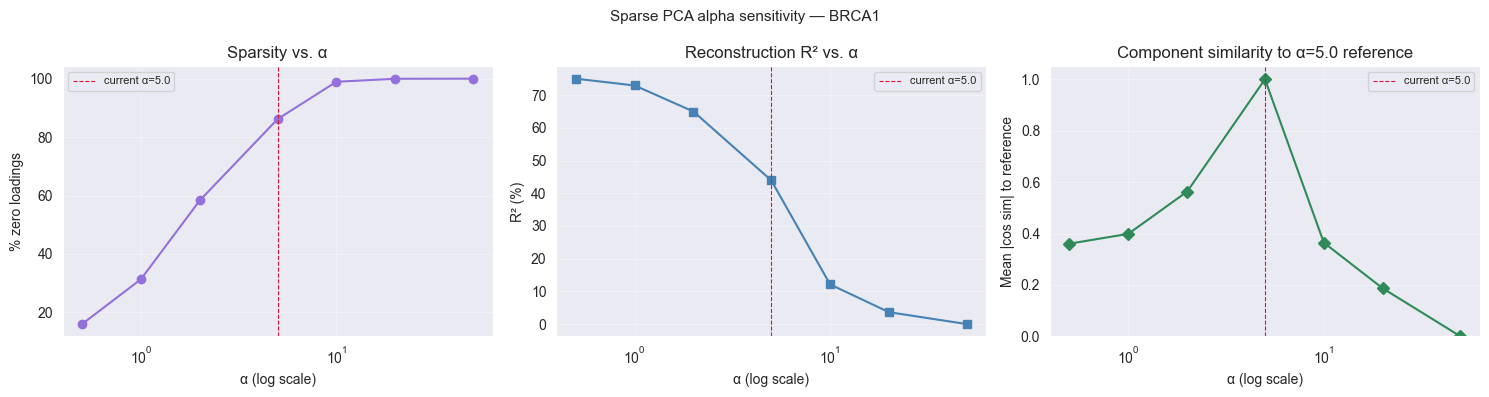

In [90]:
# ── Fig 1: Stability heatmap — component × bootstrap run ──────────────────────
sort_order = np.argsort(mean_stab)[::-1]   # most stable first

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          gridspec_kw={"width_ratios": [2.5, 1]})

# Heatmap
im = axes[0].imshow(boot_cos[:, sort_order].T, aspect="auto",
                    cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")
axes[0].set_yticks(range(N_COMPONENTS))
axes[0].set_yticklabels([f"SPC{sort_order[k]+1}" for k in range(N_COMPONENTS)], fontsize=9)
axes[0].set_xlabel("Bootstrap run")
axes[0].set_title("|Cosine similarity| to reference component\n(rows sorted by mean stability)")
plt.colorbar(im, ax=axes[0], label="|cos sim|", shrink=0.9)

# Summary bar chart with error bars
y = np.arange(N_COMPONENTS)
axes[1].barh(y, mean_stab[sort_order], xerr=std_stab[sort_order],
             color=[plt.cm.RdYlGn(v) for v in mean_stab[sort_order]],
             edgecolor="white", height=0.7, capsize=3)
axes[1].set_yticks(y)
axes[1].set_yticklabels([f"SPC{sort_order[k]+1}" for k in range(N_COMPONENTS)], fontsize=9)
axes[1].set_xlabel("Mean |cos sim| ± std")
axes[1].set_xlim(0, 1.05)
axes[1].axvline(0.9, color="green",  linestyle="--", linewidth=0.8, label="0.9 (stable)")
axes[1].axvline(0.7, color="orange", linestyle="--", linewidth=0.8, label="0.7 (marginal)")
axes[1].legend(fontsize=7)
axes[1].set_title("Mean bootstrap stability")

fig.suptitle(f"Sparse PCA bootstrap stability  (N={N_BOOTSTRAP}, frac={BOOT_FRAC}, α={ALPHA})",
             fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_bootstrap_stability.png"), dpi=150)
plt.show()

# ── Fig 2: Loading vectors for most vs. least stable component ────────────────
most_stable_k  = sort_order[0]
least_stable_k = sort_order[-1]

fig, axes = plt.subplots(2, 1, figsize=(18, 6), sharex=True)
for ax, k, label in [
    (axes[0], most_stable_k,  f"Most stable  — SPC{most_stable_k+1}  (mean={mean_stab[most_stable_k]:.3f})"),
    (axes[1], least_stable_k, f"Least stable — SPC{least_stable_k+1}  (mean={mean_stab[least_stable_k]:.3f})"),
]:
    mean_load = boot_load[:, k, :].mean(axis=0)   # mean over bootstrap runs
    std_load  = boot_load[:, k, :].std(axis=0)
    dims      = np.arange(X.shape[1])

    ax.fill_between(dims, mean_load - std_load, mean_load + std_load,
                    alpha=0.3, color="steelblue", label="±1 std")
    ax.plot(dims, mean_load, color="steelblue", linewidth=0.7, label="mean loading")
    # Reference component in orange
    ax.plot(dims, ref_comps[k], color="crimson", linewidth=0.6, alpha=0.7, label="reference")
    ax.axhline(0, color="black", linewidth=0.4)
    ax.set_ylabel("Loading weight", fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7, loc="upper right")
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel("Embedding dimension")
fig.suptitle("Bootstrap loading distributions: reference vs. bootstrapped mean ± std", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_loading_stability.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Fig 3: Alpha sensitivity ───────────────────────────────────────────────────
alphas       = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
sparsity_a   = []
r2_a         = []
mean_stab_a  = []   # mean stability across components at each alpha

X_c_local = X - X.mean(axis=0)
ss_tot     = np.sum(X_c_local ** 2)
ref_a      = None   # reference from alpha=1 for cosine-sim comparison

for a in tqdm(alphas, desc="Alpha sweep"):
    m  = MiniBatchSparsePCA(n_components=N_COMPONENTS, alpha=a,
                            max_iter=50, batch_size=200, random_state=42, n_jobs=-1)
    sc = m.fit_transform(X)
    c  = m.components_
    sparsity_a.append((c == 0).mean() * 100)
    r2_a.append(1 - np.sum((X_c_local - sc @ c) ** 2) / ss_tot)

    # Track cosine similarity of each component to the α=ALPHA reference
    cn = np.linalg.norm(c, axis=1, keepdims=True) + 1e-12
    cos_to_ref = np.abs((ref_comps @ c.T) / (ref_norms * cn.T))
    row_i, col_i = linear_sum_assignment(-cos_to_ref)
    mean_stab_a.append(cos_to_ref[row_i, col_i].mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogx(alphas, sparsity_a, "o-", color="mediumpurple")
axes[0].axvline(ALPHA, color="crimson", linestyle="--", linewidth=0.8, label=f"current α={ALPHA}")
axes[0].set_xlabel("α (log scale)")
axes[0].set_ylabel("% zero loadings")
axes[0].set_title("Sparsity vs. α")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].semilogx(alphas, [v * 100 for v in r2_a], "s-", color="steelblue")
axes[1].axvline(ALPHA, color="crimson", linestyle="--", linewidth=0.8, label=f"current α={ALPHA}")
axes[1].set_xlabel("α (log scale)")
axes[1].set_ylabel("R² (%)")
axes[1].set_title("Reconstruction R² vs. α")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

axes[2].semilogx(alphas, mean_stab_a, "D-", color="seagreen")
axes[2].axvline(ALPHA, color="crimson", linestyle="--", linewidth=0.8, label=f"current α={ALPHA}")
axes[2].set_xlabel("α (log scale)")
axes[2].set_ylabel("Mean |cos sim| to reference")
axes[2].set_title(f"Component similarity to α={ALPHA} reference")
axes[2].set_ylim(0, 1.05)
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

fig.suptitle(f"Sparse PCA alpha sensitivity — {SPCA_DATASET}", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_alpha_sensitivity.png"), dpi=150)
plt.show()

---
## SPCA Stability Grid: All Datasets × All 34 PLM Layers

For each of the 5 datasets and 34 ESM2-650M layers we run a **split-half stability analysis**: fit Sparse PCA on 4 independent 70% subsamples of the embeddings (capped at 2000 sequences per dataset for speed), then measure the mean absolute cosine similarity between matched components across all $\binom{4}{2}=6$ pairs of splits after optimal Hungarian assignment.

A high stability score means the sparse components are reliably recovered regardless of which sequences happen to be in the training set — a necessary (if not sufficient) condition for interpreting those components as biologically meaningful.

After building the full stability grid we ask:
- **Which (dataset, layer) combinations are most stable?**
- **Do stable layers coincide across datasets?** (Cross-dataset layer alignment)

In [91]:
import re
from itertools import combinations

# ── Grid hyperparameters ──────────────────────────────────────────────────────
GRID_DATASETS   = ["BRCA1", "TpoR", "Ube4b", "BF520", "BG505"]
GRID_ALPHA      = 5.0
GRID_K          = 5      # sparse components per (dataset, layer)
GRID_MAX_ITER   = 20     # SPCA iterations per split fit
GRID_N_SPLITS   = 4      # independent subsample fits; C(4,2)=6 pairs compared
GRID_SPLIT_FRAC = 0.70   # fraction of (capped) sequences per split
GRID_N_MAX_SEQS = 2000   # cap large datasets for speed
GRID_SEED       = 42

rng_grid = np.random.default_rng(GRID_SEED)

# Discover available layers for each dataset (union of all datasets)
all_layers = set()
dataset_layers = {}
for ds in GRID_DATASETS:
    dpath = os.path.join(ESMDIR, "data/sequence_data", ds)
    if not os.path.isdir(dpath):
        continue
    layers = sorted(int(m.group(1))
                    for f in os.listdir(dpath)
                    if (m := re.match(r"layer(\d+)_seq_to_emb\.pkl", f)))
    dataset_layers[ds] = layers
    all_layers.update(layers)

all_layers = sorted(all_layers)
avail_datasets = list(dataset_layers.keys())
print(f"Datasets      : {avail_datasets}")
print(f"Layers        : {min(all_layers)}–{max(all_layers)}  ({len(all_layers)} total)")
print(f"Grid size     : {len(avail_datasets)} × {len(all_layers)} = {len(avail_datasets)*len(all_layers)} fits × {GRID_N_SPLITS} splits")

# ── Compute stability grid ────────────────────────────────────────────────────
# stability_grid[ds][layer] = mean |cos sim| across all split pairs
stability_grid = {ds: {} for ds in avail_datasets}

outer = tqdm(avail_datasets, desc="Dataset", position=0)
for ds in outer:
    outer.set_postfix(dataset=ds)
    inner = tqdm(dataset_layers[ds], desc=f"  {ds} layers", position=1, leave=False)
    for layer in inner:
        emb_path = os.path.join(ESMDIR, "data/sequence_data", ds, f"layer{layer}_seq_to_emb.pkl")
        X_full   = pd.read_pickle(emb_path)

        # Cap large datasets
        if len(X_full) > GRID_N_MAX_SEQS:
            idx = rng_grid.choice(len(X_full), GRID_N_MAX_SEQS, replace=False)
            X_g = X_full[idx]
        else:
            X_g = X_full

        # Fit GRID_N_SPLITS independent SPCA models on random subsamples
        split_comps = []
        split_size  = int(len(X_g) * GRID_SPLIT_FRAC)
        for s in range(GRID_N_SPLITS):
            idx_s = rng_grid.choice(len(X_g), split_size, replace=False)
            m = MiniBatchSparsePCA(
                n_components=GRID_K, alpha=GRID_ALPHA,
                max_iter=GRID_MAX_ITER, batch_size=200,
                random_state=GRID_SEED + s, n_jobs=-1,
            )
            m.fit(X_g[idx_s])
            split_comps.append(m.components_)   # (K, D)

        # Compare every pair of splits via Hungarian-matched |cos sim|
        pair_sims = []
        for (ca, cb) in combinations(split_comps, 2):
            na = np.linalg.norm(ca, axis=1, keepdims=True) + 1e-12
            nb = np.linalg.norm(cb, axis=1, keepdims=True) + 1e-12
            cos_mat = np.abs((ca @ cb.T) / (na * nb.T))
            ri, ci  = linear_sum_assignment(-cos_mat)
            pair_sims.append(cos_mat[ri, ci].mean())

        stability_grid[ds][layer] = float(np.mean(pair_sims))

print("\nDone. Sample stability scores (layer 24):")
for ds in avail_datasets:
    print(f"  {ds}: {stability_grid[ds].get(24, float('nan')):.3f}")

Datasets      : ['BRCA1', 'TpoR', 'Ube4b', 'BF520', 'BG505']
Layers        : 0–33  (34 total)
Grid size     : 5 × 34 = 170 fits × 4 splits


Dataset:   0%|          | 0/5 [00:00<?, ?it/s]

  BRCA1 layers:   0%|          | 0/34 [00:00<?, ?it/s]

  TpoR layers:   0%|          | 0/34 [00:00<?, ?it/s]

  Ube4b layers:   0%|          | 0/34 [00:00<?, ?it/s]

  BF520 layers:   0%|          | 0/34 [00:00<?, ?it/s]

  BG505 layers:   0%|          | 0/34 [00:00<?, ?it/s]


Done. Sample stability scores (layer 24):
  BRCA1: 0.630
  TpoR: 0.698
  Ube4b: 0.400
  BF520: 0.200
  BG505: 0.200


Top-5 most stable layers per dataset:
  BRCA1     : L27=0.715  L31=0.702  L32=0.695  L30=0.640  L24=0.630
  TpoR      : L31=0.856  L32=0.846  L29=0.797  L14=0.782  L27=0.779
  Ube4b     : L32=0.736  L31=0.705  L23=0.575  L16=0.511  L15=0.508
  BF520     : L26=0.400  L32=0.359  L30=0.298  L23=0.233  L29=0.231
  BG505     : L32=0.600  L26=0.300  L31=0.208  L16=0.200  L22=0.200

Top-5 layers by mean stability across all datasets:
  Layer 32: 0.647
  Layer 31: 0.535
  Layer 26: 0.493
  Layer 27: 0.479
  Layer 30: 0.475


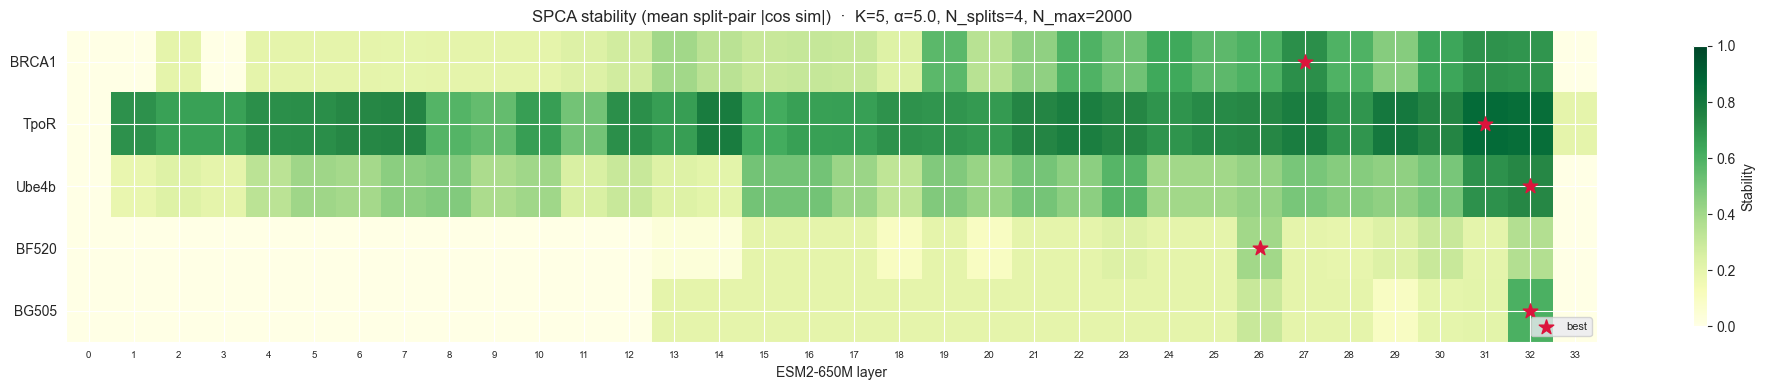

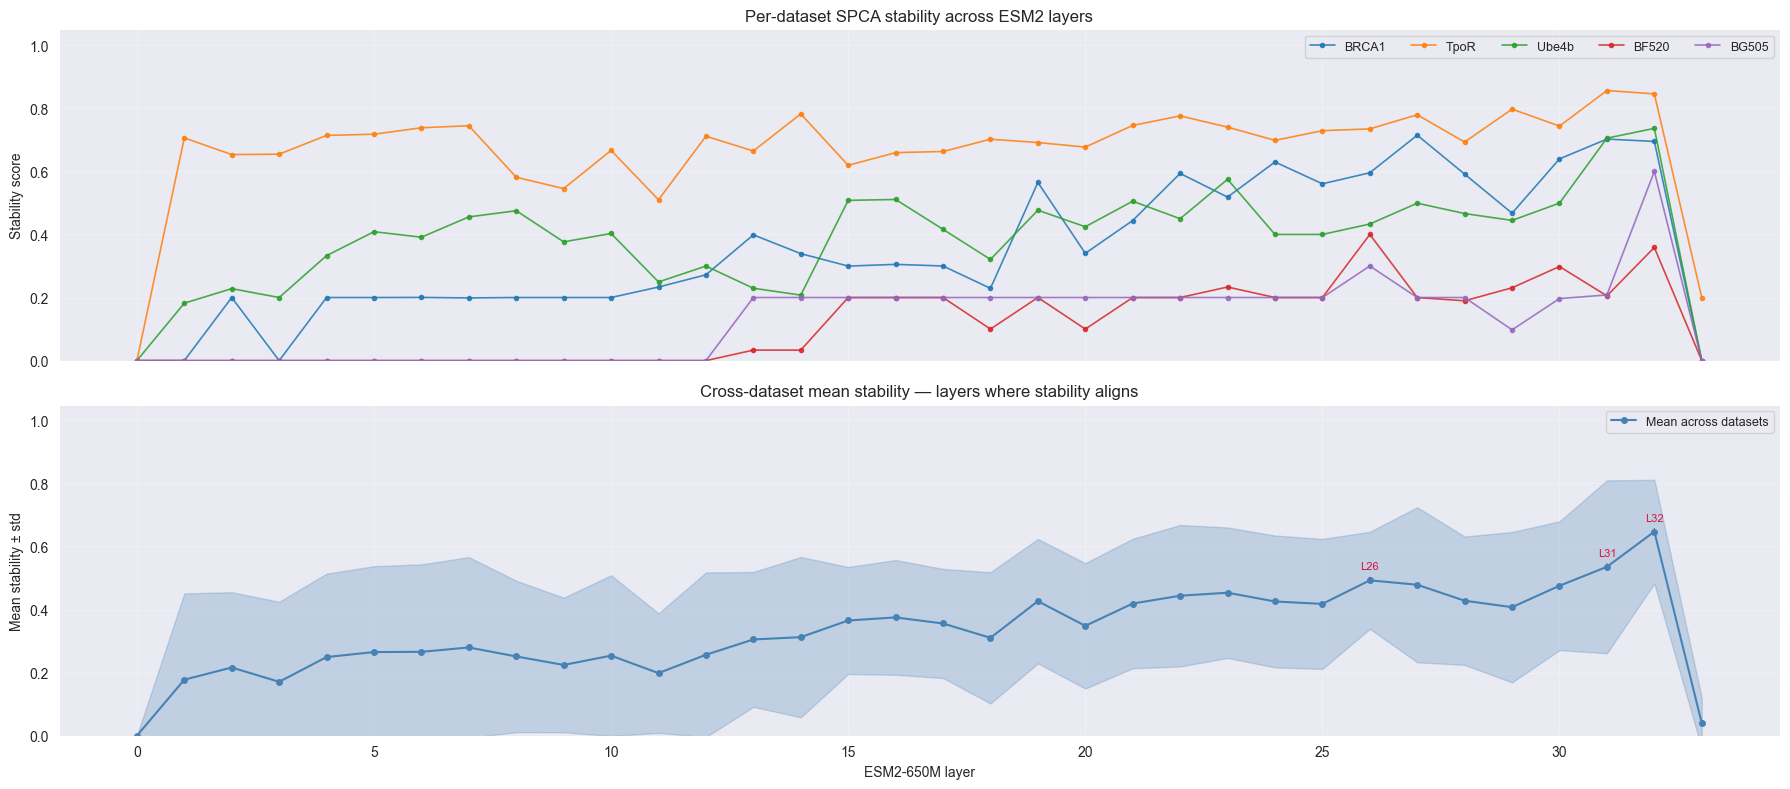


Layers stable across ALL datasets: [32]


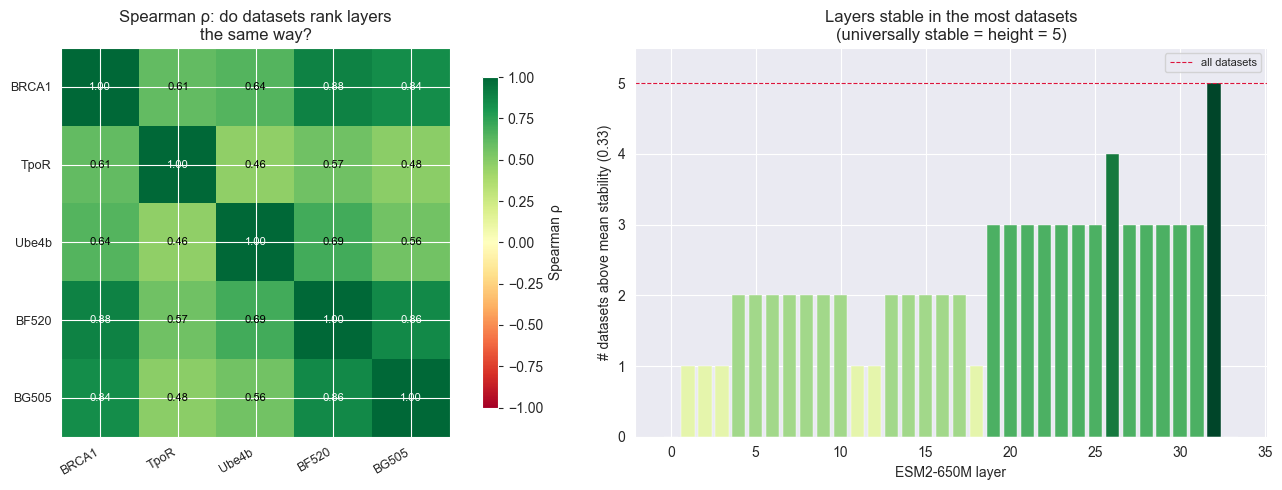

In [92]:
from scipy.stats import spearmanr

# ── Build matrix: (n_datasets, n_layers) ──────────────────────────────────────
stab_matrix = np.full((len(avail_datasets), len(all_layers)), np.nan)
for di, ds in enumerate(avail_datasets):
    for li, layer in enumerate(all_layers):
        stab_matrix[di, li] = stability_grid[ds].get(layer, np.nan)

# ── Summaries ─────────────────────────────────────────────────────────────────
# Per-dataset best layers
print("Top-5 most stable layers per dataset:")
for di, ds in enumerate(avail_datasets):
    row = stab_matrix[di]
    top_li = np.argsort(row)[::-1][:5]
    top_str = "  ".join(f"L{all_layers[li]}={row[li]:.3f}" for li in top_li)
    print(f"  {ds:<10}: {top_str}")

# Cross-dataset mean stability per layer
mean_by_layer = np.nanmean(stab_matrix, axis=0)   # (n_layers,)
top_layer_idx = np.argsort(mean_by_layer)[::-1][:5]
print(f"\nTop-5 layers by mean stability across all datasets:")
for li in top_layer_idx:
    print(f"  Layer {all_layers[li]:>2}: {mean_by_layer[li]:.3f}")

# ── Fig 1: Heatmap ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 4))
im = ax.imshow(stab_matrix, aspect="auto", cmap="YlGn",
               vmin=0, vmax=1, interpolation="nearest")
ax.set_yticks(range(len(avail_datasets)))
ax.set_yticklabels(avail_datasets, fontsize=10)
ax.set_xticks(range(len(all_layers)))
ax.set_xticklabels([str(l) for l in all_layers], fontsize=7, rotation=0)
ax.set_xlabel("ESM2-650M layer")
ax.set_title(f"SPCA stability (mean split-pair |cos sim|)  ·  K={GRID_K}, α={GRID_ALPHA}, "
             f"N_splits={GRID_N_SPLITS}, N_max={GRID_N_MAX_SEQS}")
plt.colorbar(im, ax=ax, label="Stability", shrink=0.9)

# Mark best layer per dataset
for di in range(len(avail_datasets)):
    best_li = np.nanargmax(stab_matrix[di])
    ax.scatter(best_li, di, marker="*", s=120, color="crimson",
               zorder=5, label="best" if di == 0 else "")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_grid_stability_heatmap.png"), dpi=150)
plt.show()

# ── Fig 2: Per-layer mean stability + per-dataset lines ───────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

layer_x = np.array(all_layers)
ds_colors_g = dict(zip(avail_datasets, plt.cm.tab10.colors[:len(avail_datasets)]))

# Top panel: individual dataset stability curves
for di, ds in enumerate(avail_datasets):
    axes[0].plot(layer_x, stab_matrix[di], "-o", markersize=3, linewidth=1.2,
                 color=ds_colors_g[ds], label=ds, alpha=0.85)
axes[0].set_ylabel("Stability score")
axes[0].set_title("Per-dataset SPCA stability across ESM2 layers")
axes[0].legend(fontsize=9, ncol=len(avail_datasets))
axes[0].grid(alpha=0.25)
axes[0].set_ylim(0, 1.05)

# Bottom panel: mean ± std across datasets
std_by_layer  = np.nanstd(stab_matrix, axis=0)
axes[1].fill_between(layer_x, mean_by_layer - std_by_layer,
                     mean_by_layer + std_by_layer, alpha=0.25, color="steelblue")
axes[1].plot(layer_x, mean_by_layer, "-o", markersize=4, linewidth=1.5,
             color="steelblue", label="Mean across datasets")

# Annotate top-3 cross-dataset stable layers
for rank, li in enumerate(top_layer_idx[:3]):
    axes[1].annotate(f"L{all_layers[li]}",
                     xy=(all_layers[li], mean_by_layer[li]),
                     xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=8, color="crimson",
                     arrowprops=dict(arrowstyle="-", color="crimson", lw=0.8))

axes[1].set_xlabel("ESM2-650M layer")
axes[1].set_ylabel("Mean stability ± std")
axes[1].set_title("Cross-dataset mean stability — layers where stability aligns")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_grid_layer_stability.png"), dpi=150)
plt.show()

# ── Fig 3: Cross-dataset alignment — Spearman rank correlation matrix ──────────
# High Spearman r means two datasets rank layers similarly in terms of stability
spear_mat = np.full((len(avail_datasets), len(avail_datasets)), np.nan)
for i, dsi in enumerate(avail_datasets):
    for j, dsj in enumerate(avail_datasets):
        if i == j:
            spear_mat[i, j] = 1.0
        else:
            r, _ = spearmanr(stab_matrix[i], stab_matrix[j])
            spear_mat[i, j] = r

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spearman matrix heatmap
im = axes[0].imshow(spear_mat, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(avail_datasets)))
axes[0].set_yticks(range(len(avail_datasets)))
axes[0].set_xticklabels(avail_datasets, rotation=30, ha="right", fontsize=9)
axes[0].set_yticklabels(avail_datasets, fontsize=9)
axes[0].set_title("Spearman ρ: do datasets rank layers\nthe same way?")
plt.colorbar(im, ax=axes[0], label="Spearman ρ", shrink=0.85)
for i in range(len(avail_datasets)):
    for j in range(len(avail_datasets)):
        axes[0].text(j, i, f"{spear_mat[i,j]:.2f}", ha="center", va="center",
                     fontsize=8, color="black" if abs(spear_mat[i,j]) < 0.7 else "white")

# "Universally stable" layers: above mean + 0.5*std in every dataset
threshold = np.nanmean(stab_matrix) + 0.0 * np.nanstd(stab_matrix)
n_datasets_stable = (stab_matrix > threshold).sum(axis=0)   # (n_layers,)
colors_bar = [plt.cm.YlGn(v / len(avail_datasets)) for v in n_datasets_stable]
axes[1].bar(layer_x, n_datasets_stable, color=colors_bar, edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("ESM2-650M layer")
axes[1].set_ylabel(f"# datasets above mean stability ({threshold:.2f})")
axes[1].set_title("Layers stable in the most datasets\n(universally stable = height = 5)")
axes[1].axhline(len(avail_datasets), color="crimson", linestyle="--",
                linewidth=0.8, label="all datasets")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, len(avail_datasets) + 0.5)

# Annotate layers where all datasets are above threshold
universal = [all_layers[li] for li in range(len(all_layers))
             if n_datasets_stable[li] == len(avail_datasets)]
if universal:
    print(f"\nLayers stable across ALL datasets: {universal}")
else:
    nearly = [all_layers[li] for li in range(len(all_layers))
              if n_datasets_stable[li] >= len(avail_datasets) - 1]
    print(f"\nLayers stable in ≥{len(avail_datasets)-1} datasets: {nearly}")

plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_grid_cross_dataset_alignment.png"), dpi=150)
plt.show()

### Per-component Stability and Sparsity Grid

The previous analysis averaged stability across all $K$ components. Here we break it down **per component** to count how many fall in each zone:

| Zone | Criterion |
|---|---|
| Stable | $\lvert\cos\text{ sim}\rvert > 0.9$ |
| Marginal | $0.7 < \lvert\cos\text{ sim}\rvert \leq 0.9$ |
| Unstable | $\lvert\cos\text{ sim}\rvert \leq 0.7$ |

We also track the **sparsity** of each (dataset, layer) fit — the fraction of loading weights that are exactly zero — since sparsity and stability are often in tension: high-$\alpha$ models are sparser but harder to recover consistently.

In [93]:
# Two independent splits per (dataset, layer) → 1 pairwise comparison.
# Split 0 is also used for sparsity. Faster than the 4-split grid above.
DETAIL_N_SPLITS  = 3    # C(3,2) = 3 pairs → per-component mean over 3 comparisons
DETAIL_SEED      = 99   # independent from the grid scan above
rng_detail       = np.random.default_rng(DETAIL_SEED)

# per_comp_stab[ds][layer] → array (K,) of mean |cos sim| per component
# sparsity_pct[ds][layer]  → float, % zero loadings (from split-0 components)
per_comp_stab = {ds: {} for ds in avail_datasets}
sparsity_pct  = {ds: {} for ds in avail_datasets}

outer = tqdm(avail_datasets, desc="Dataset", position=0)
for ds in outer:
    inner = tqdm(dataset_layers[ds], desc=f"  {ds}", position=1, leave=False)
    for layer in inner:
        X_full = pd.read_pickle(
            os.path.join(ESMDIR, "data/sequence_data", ds, f"layer{layer}_seq_to_emb.pkl")
        )
        if len(X_full) > GRID_N_MAX_SEQS:
            X_g = X_full[rng_detail.choice(len(X_full), GRID_N_MAX_SEQS, replace=False)]
        else:
            X_g = np.array(X_full)

        split_size = int(len(X_g) * GRID_SPLIT_FRAC)
        split_comps = []
        for s in range(DETAIL_N_SPLITS):
            idx_s = rng_detail.choice(len(X_g), split_size, replace=False)
            m = MiniBatchSparsePCA(
                n_components=GRID_K, alpha=GRID_ALPHA,
                max_iter=GRID_MAX_ITER, batch_size=200,
                random_state=DETAIL_SEED + s, n_jobs=-1,
            )
            m.fit(X_g[idx_s])
            split_comps.append(m.components_)   # (K, D)

        # Sparsity from the first split
        sparsity_pct[ds][layer] = float((split_comps[0] == 0).mean() * 100)

        # Per-component stability: average |cos sim| per component across all pairs
        comp_sim_accum = np.zeros(GRID_K)
        n_pairs = 0
        for ca, cb in combinations(split_comps, 2):
            na = np.linalg.norm(ca, axis=1, keepdims=True) + 1e-12
            nb = np.linalg.norm(cb, axis=1, keepdims=True) + 1e-12
            cos_mat        = np.abs((ca @ cb.T) / (na * nb.T))
            ri, ci         = linear_sum_assignment(-cos_mat)
            # Accumulate matched similarities in reference (split-0 / row) order
            comp_sims      = np.zeros(GRID_K)
            comp_sims[ri]  = cos_mat[ri, ci]
            comp_sim_accum += comp_sims
            n_pairs        += 1

        per_comp_stab[ds][layer] = comp_sim_accum / n_pairs   # (K,)

print("Done.")

Dataset:   0%|          | 0/5 [00:00<?, ?it/s]

  BRCA1:   0%|          | 0/34 [00:00<?, ?it/s]

  TpoR:   0%|          | 0/34 [00:00<?, ?it/s]

  Ube4b:   0%|          | 0/34 [00:00<?, ?it/s]

  BF520:   0%|          | 0/34 [00:00<?, ?it/s]

  BG505:   0%|          | 0/34 [00:00<?, ?it/s]

Done.


In [97]:
GRID_K = 5

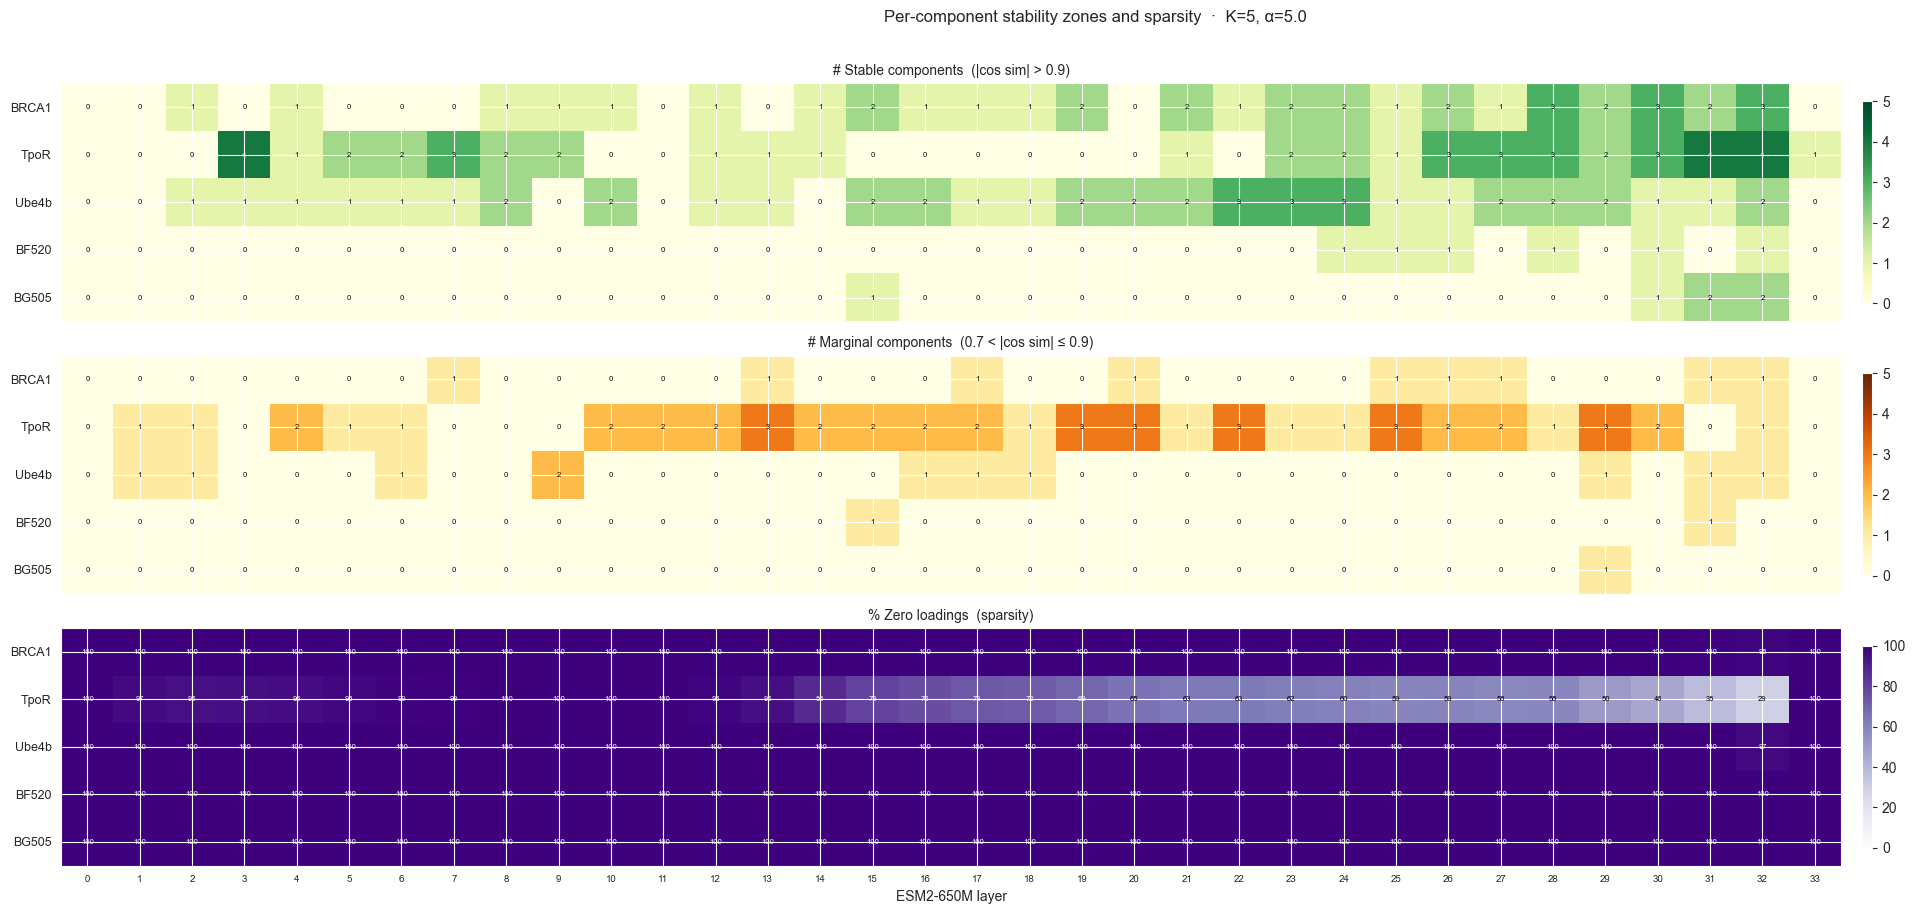

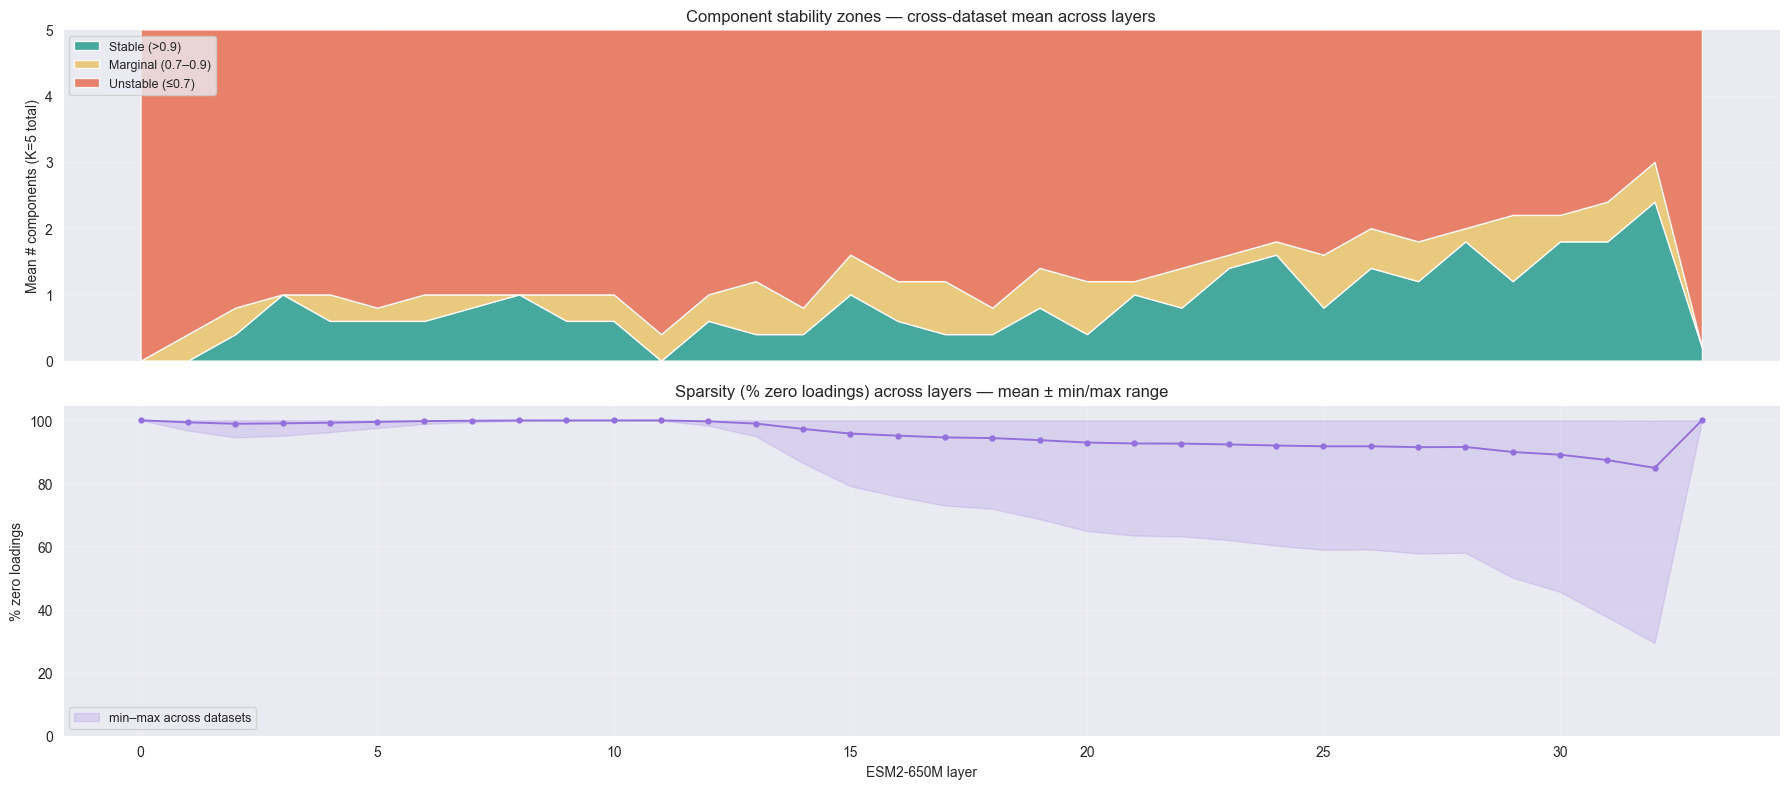

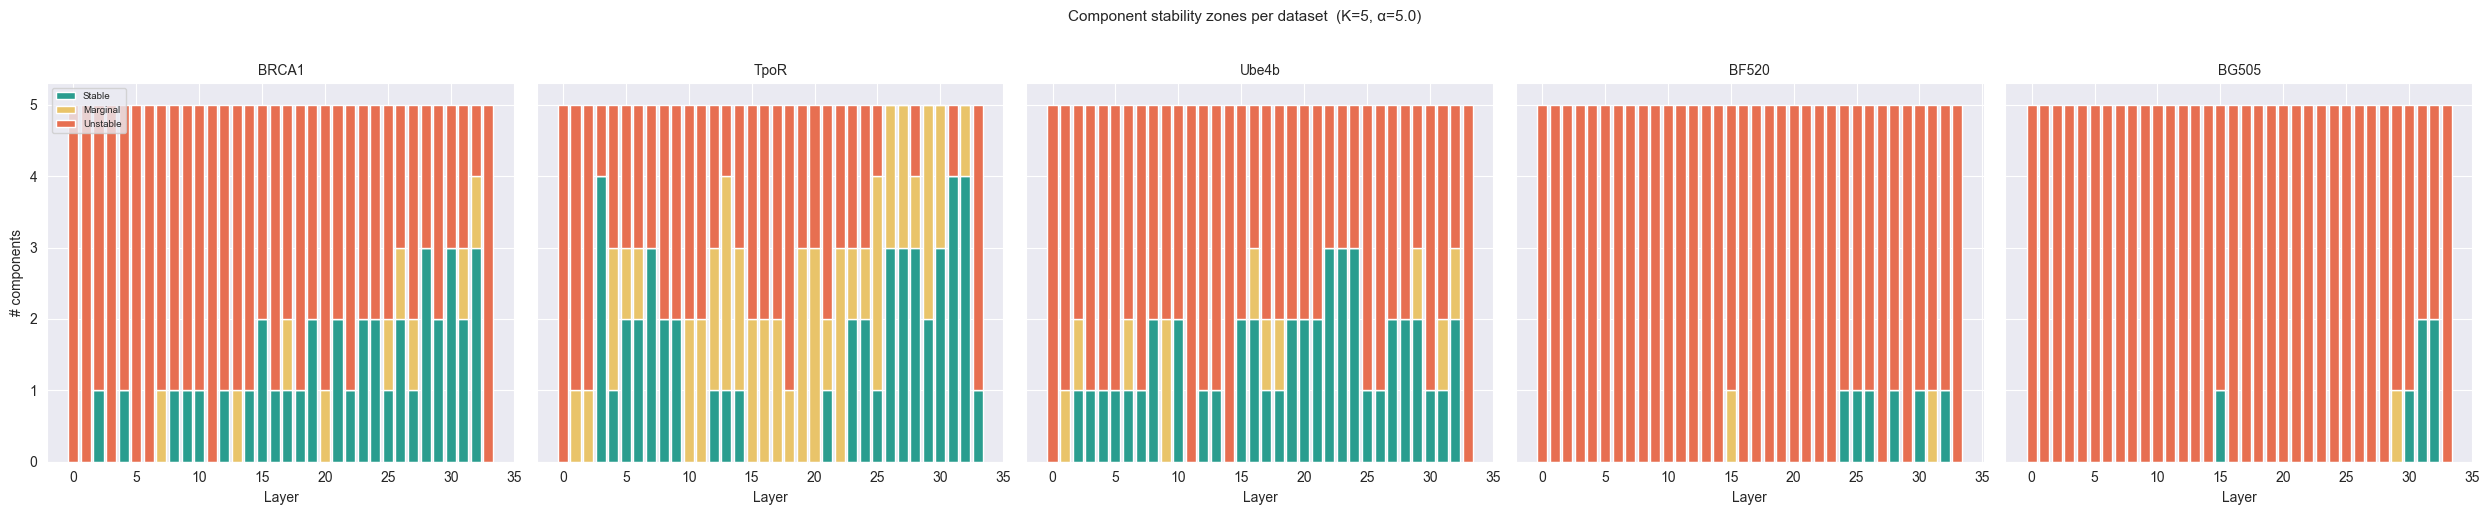


Top layers by mean stable components (cross-dataset):
  Layer 32: 2.40 stable  | 0.60 marginal  | 84.9% zeros
  Layer 31: 1.80 stable  | 0.60 marginal  | 87.4% zeros
  Layer 30: 1.80 stable  | 0.40 marginal  | 89.1% zeros
  Layer 28: 1.80 stable  | 0.20 marginal  | 91.5% zeros
  Layer 24: 1.60 stable  | 0.20 marginal  | 92.0% zeros


In [98]:
STABLE_THR   = 0.9
MARGINAL_THR = 0.7

D_ds = len(avail_datasets)
D_ly = len(all_layers)

# Build (n_datasets, n_layers) matrices
n_stable   = np.full((D_ds, D_ly), np.nan)
n_marginal = np.full((D_ds, D_ly), np.nan)
n_unstable = np.full((D_ds, D_ly), np.nan)
sparsity_m = np.full((D_ds, D_ly), np.nan)

for di, ds in enumerate(avail_datasets):
    for li, layer in enumerate(all_layers):
        if layer not in per_comp_stab[ds]:
            continue
        stabs = per_comp_stab[ds][layer]   # (K,)
        n_stable[di, li]   = (stabs > STABLE_THR).sum()
        n_marginal[di, li] = ((stabs > MARGINAL_THR) & (stabs <= STABLE_THR)).sum()
        n_unstable[di, li] = (stabs <= MARGINAL_THR).sum()
        sparsity_m[di, li] = sparsity_pct[ds][layer]

# ── Fig 1: Three heatmaps stacked (stable / marginal / sparsity) ──────────────
fig, axes = plt.subplots(3, 1, figsize=(22, 9), sharex=True)

panels = [
    (n_stable,   "# Stable components  (|cos sim| > 0.9)",         "YlGn",   0, GRID_K),
    (n_marginal, "# Marginal components  (0.7 < |cos sim| ≤ 0.9)", "YlOrBr", 0, GRID_K),
    (sparsity_m, "% Zero loadings  (sparsity)",                    "Purples", 0, 100),
]
for ax, (mat, title, cmap, vmin, vmax) in zip(axes, panels):
    im = ax.imshow(mat, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation="nearest")
    ax.set_yticks(range(D_ds))
    ax.set_yticklabels(avail_datasets, fontsize=9)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.85, pad=0.01)
    # Annotate cells
    for di in range(D_ds):
        for li in range(D_ly):
            val = mat[di, li]
            if np.isnan(val):
                continue
            txt = f"{val:.0f}" if vmax == 100 else f"{int(val)}"
            ax.text(li, di, txt, ha="center", va="center", fontsize=5.5,
                    color="white" if val > vmax * 0.65 else "black")

axes[-1].set_xticks(range(D_ly))
axes[-1].set_xticklabels([str(l) for l in all_layers], fontsize=7)
axes[-1].set_xlabel("ESM2-650M layer")
fig.suptitle(f"Per-component stability zones and sparsity  ·  K={GRID_K}, α={GRID_ALPHA}",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_component_zones_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── Fig 2: Cross-dataset mean of each metric vs layer (line plots) ────────────
mean_stable   = np.nanmean(n_stable,   axis=0)
mean_marginal = np.nanmean(n_marginal, axis=0)
mean_unstable = np.nanmean(n_unstable, axis=0)
mean_sparsity = np.nanmean(sparsity_m, axis=0)

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

# Stacked area — counts of stable / marginal / unstable
lx = np.array(all_layers)
axes[0].stackplot(lx,
    mean_stable, mean_marginal, mean_unstable,
    labels=["Stable (>0.9)", "Marginal (0.7–0.9)", "Unstable (≤0.7)"],
    colors=["#2a9d8f", "#e9c46a", "#e76f51"],
    alpha=0.85,
)
axes[0].set_ylabel(f"Mean # components (K={GRID_K} total)")
axes[0].set_title("Component stability zones — cross-dataset mean across layers")
axes[0].set_ylim(0, GRID_K)
axes[0].legend(loc="upper left", fontsize=9)
axes[0].grid(alpha=0.2)

# Sparsity line
axes[1].plot(lx, mean_sparsity, "-o", markersize=3.5, color="mediumpurple", linewidth=1.4)
axes[1].fill_between(lx,
    np.nanmin(sparsity_m, axis=0),
    np.nanmax(sparsity_m, axis=0),
    alpha=0.2, color="mediumpurple", label="min–max across datasets",
)
axes[1].set_ylabel("% zero loadings")
axes[1].set_xlabel("ESM2-650M layer")
axes[1].set_title("Sparsity (% zero loadings) across layers — mean ± min/max range")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_zones_by_layer.png"), dpi=150)
plt.show()

# ── Fig 3: Per-dataset breakdown bars (stable / marginal / unstable stacked) ──
fig, axes = plt.subplots(1, D_ds, figsize=(5 * D_ds, 5), sharey=True)
for di, (ax, ds) in enumerate(zip(axes, avail_datasets)):
    ax.bar(lx, n_stable[di],                              color="#2a9d8f", label="Stable")
    ax.bar(lx, n_marginal[di], bottom=n_stable[di],       color="#e9c46a", label="Marginal")
    ax.bar(lx, n_unstable[di],
           bottom=n_stable[di] + n_marginal[di],          color="#e76f51", label="Unstable")
    ax.set_title(ds, fontsize=10)
    ax.set_xlabel("Layer")
    ax.set_ylim(0, GRID_K + 0.3)
    if di == 0:
        ax.set_ylabel("# components")
        ax.legend(fontsize=7, loc="upper left")

plt.suptitle(f"Component stability zones per dataset  (K={GRID_K}, α={GRID_ALPHA})",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "spca_zones_per_dataset.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\nTop layers by mean stable components (cross-dataset):")
top5 = np.argsort(mean_stable)[::-1][:5]
for li in top5:
    print(f"  Layer {all_layers[li]:>2}: {mean_stable[li]:.2f} stable  "
          f"| {mean_marginal[li]:.2f} marginal  | {mean_sparsity[li]:.1f}% zeros")

---
## SPCA vs PCA with Varimax Rotation

Both methods try to produce interpretable components from PCA, but take opposite approaches:

| Property | Sparse PCA | PCA + Varimax |
|---|---|---|
| How sparsity is achieved | L1 penalty forces exact zeros | Orthogonal rotation maximises loading variance (no exact zeros) |
| Subspace | Different from PCA | Same as PCA (rotation preserves subspace) |
| Orthogonality | Components not orthogonal | Components remain orthogonal |
| Reconstruction | Lower R² (sparsity cost) | Identical R² to PCA |

We compare loading structure, bootstrap stability, score geometry, and subspace overlap.

In [99]:
def varimax(loadings, gamma=1.0, max_iter=1000, tol=1e-6):
    """
    Varimax rotation via iterative SVD.
    loadings : (n_components, n_features)  — sklearn convention
    Returns  : rotated_loadings (n_components, n_features),
               rotation_matrix  (n_components, n_components)
    """
    L = loadings.T          # (p, k)
    p, k = L.shape
    R = np.eye(k)
    for _ in range(max_iter):
        Lr     = L @ R
        A      = L.T @ (Lr**3 - (gamma / p) * Lr @ np.diag((Lr**2).sum(axis=0)))
        u, s, vt = np.linalg.svd(A)
        R_new  = u @ vt
        if np.max(np.abs(R_new - R)) < tol:
            R = R_new
            break
        R = R_new
    return (L @ R).T, R     # (k, p), (k, k)

def subspace_angles(A, B):
    """Principal angles (degrees) between row-subspaces of A and B."""
    qa, _ = np.linalg.qr(A.T)
    qb, _ = np.linalg.qr(B.T)
    _, s, _ = np.linalg.svd(qa.T @ qb)
    return np.arccos(np.clip(s, -1, 1)) * 180 / np.pi

# ── Fit Varimax on SPCA_DATASET ───────────────────────────────────────────────
var_comps, R_var = varimax(pca_comps_s)   # rotate the N_COMPONENTS PCA loadings
sc_varimax        = sc_pca @ R_var         # (N, K) — same subspace, rotated scores

# Reconstruction R²
X_c_var   = X - X.mean(axis=0)
r2_var    = 1 - np.sum((X_c_var - sc_varimax @ var_comps)**2) / np.sum(X_c_var**2)
r2_spca_c = 1 - np.sum((X_c_var - sc_spca @ spca_comps_s)**2) / np.sum(X_c_var**2)

# Subspace angles between methods
angles_sv = subspace_angles(spca_comps_s, var_comps)   # SPCA vs Varimax
angles_sp = subspace_angles(spca_comps_s, pca_comps_s) # SPCA vs PCA
angles_vp = subspace_angles(var_comps,    pca_comps_s) # Varimax vs PCA (~0)

print(f"R²  —  PCA: {ev_ratio.sum()*100:.2f}%  |  Varimax: {r2_var*100:.2f}%  |  SPCA: {r2_spca_c*100:.2f}%")
print(f"\nPrincipal angles (°):")
print(f"  SPCA vs Varimax : {np.round(angles_sv, 1).tolist()}")
print(f"  SPCA vs PCA     : {np.round(angles_sp, 1).tolist()}")
print(f"  Varimax vs PCA  : {np.round(angles_vp, 1).tolist()}  <- should be ~0")

# ── Bootstrap stability for Varimax ───────────────────────────────────────────
print(f"\nRunning {N_BOOTSTRAP} bootstrap runs for Varimax ...")
boot_cos_var  = np.zeros((N_BOOTSTRAP, N_COMPONENTS))
boot_load_var = np.zeros((N_BOOTSTRAP, N_COMPONENTS, X.shape[1]))

ref_var_norms = np.linalg.norm(var_comps, axis=1, keepdims=True) + 1e-12
rng_vb = np.random.default_rng(7)

for b in tqdm(range(N_BOOTSTRAP), desc="Varimax bootstrap"):
    idx      = rng_vb.choice(len(X), size=int(len(X) * BOOT_FRAC), replace=True)
    pca_b    = PCA(n_components=N_COMPONENTS, random_state=b)
    pca_b.fit(X[idx])
    vc_b, _  = varimax(pca_b.components_)
    vn       = np.linalg.norm(vc_b, axis=1, keepdims=True) + 1e-12
    cos_mat  = np.abs((var_comps @ vc_b.T) / (ref_var_norms * vn.T))
    ri, ci   = linear_sum_assignment(-cos_mat)
    for i, j in zip(ri, ci):
        boot_cos_var[b, i] = cos_mat[i, j]
        sign = np.sign(var_comps[i] @ vc_b[j])
        boot_load_var[b, i] = sign * vc_b[j]

mean_stab_var = boot_cos_var.mean(axis=0)
std_stab_var  = boot_cos_var.std(axis=0)
print("\nBootstrap stability — Varimax vs SPCA (mean |cos sim| per component):")
for k in range(N_COMPONENTS):
    print(f"  Comp {k+1}: Varimax {mean_stab_var[k]:.3f} ± {std_stab_var[k]:.3f}"
          f"   |   SPCA {mean_stab[k]:.3f} ± {std_stab[k]:.3f}")

R²  —  PCA: 75.73%  |  Varimax: 75.73%  |  SPCA: 43.94%

Principal angles (°):
  SPCA vs Varimax : [23.1, 27.1, 38.7, 40.3, 59.9, 62.2, 79.3, 85.1, 87.1, 90.0]
  SPCA vs PCA     : [23.1, 27.1, 38.7, 40.3, 59.9, 62.2, 79.3, 85.1, 87.1, 90.0]
  Varimax vs PCA  : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  <- should be ~0

Running 20 bootstrap runs for Varimax ...


Varimax bootstrap:   0%|          | 0/20 [00:00<?, ?it/s]


Bootstrap stability — Varimax vs SPCA (mean |cos sim| per component):
  Comp 1: Varimax 0.995 ± 0.006   |   SPCA 0.803 ± 0.125
  Comp 2: Varimax 0.991 ± 0.011   |   SPCA 0.750 ± 0.098
  Comp 3: Varimax 0.987 ± 0.010   |   SPCA 0.901 ± 0.051
  Comp 4: Varimax 0.989 ± 0.010   |   SPCA 0.552 ± 0.195
  Comp 5: Varimax 0.982 ± 0.034   |   SPCA 0.442 ± 0.142
  Comp 6: Varimax 0.993 ± 0.006   |   SPCA 0.640 ± 0.153
  Comp 7: Varimax 0.969 ± 0.051   |   SPCA 0.596 ± 0.156
  Comp 8: Varimax 0.990 ± 0.013   |   SPCA 0.259 ± 0.250
  Comp 9: Varimax 0.956 ± 0.072   |   SPCA 0.540 ± 0.176
  Comp 10: Varimax 0.938 ± 0.106   |   SPCA 0.512 ± 0.185


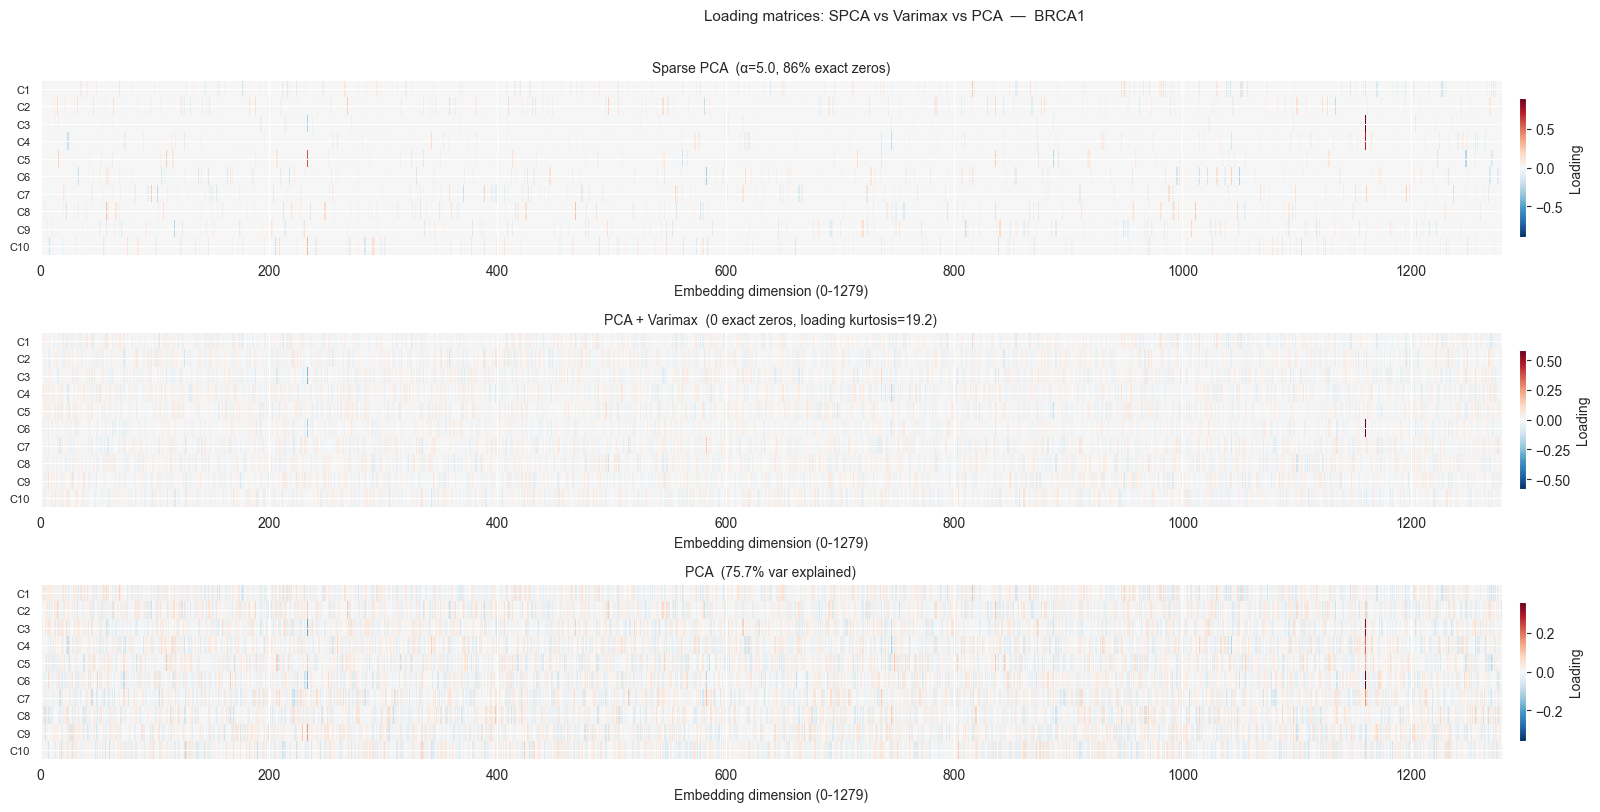

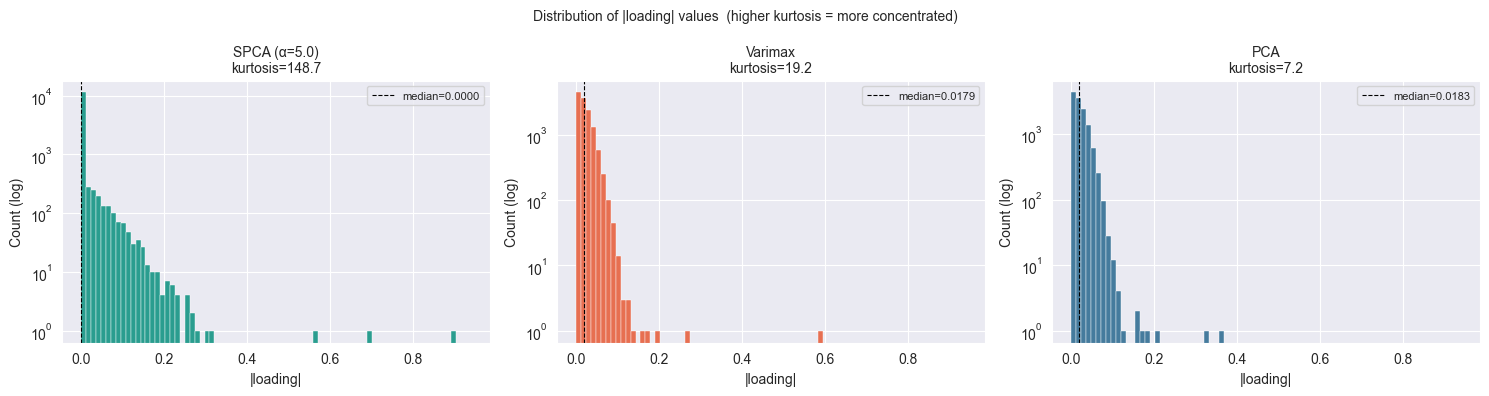

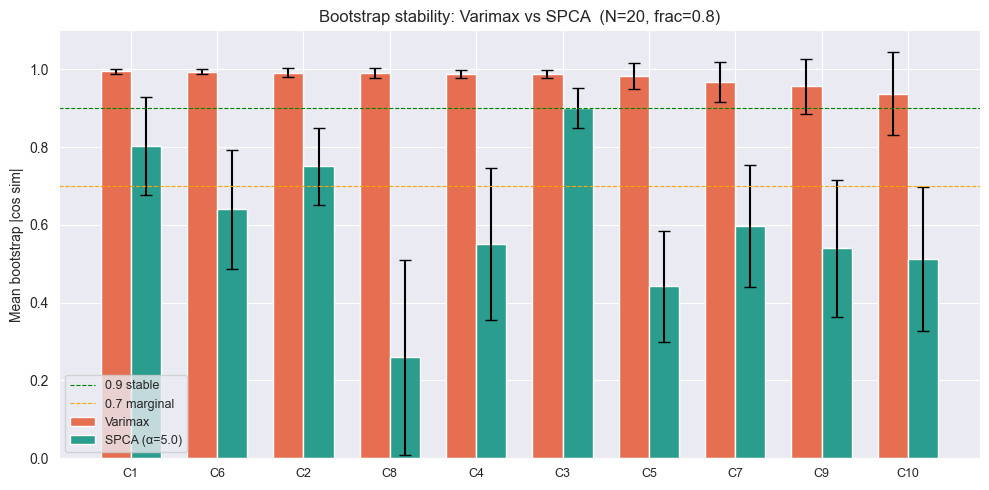

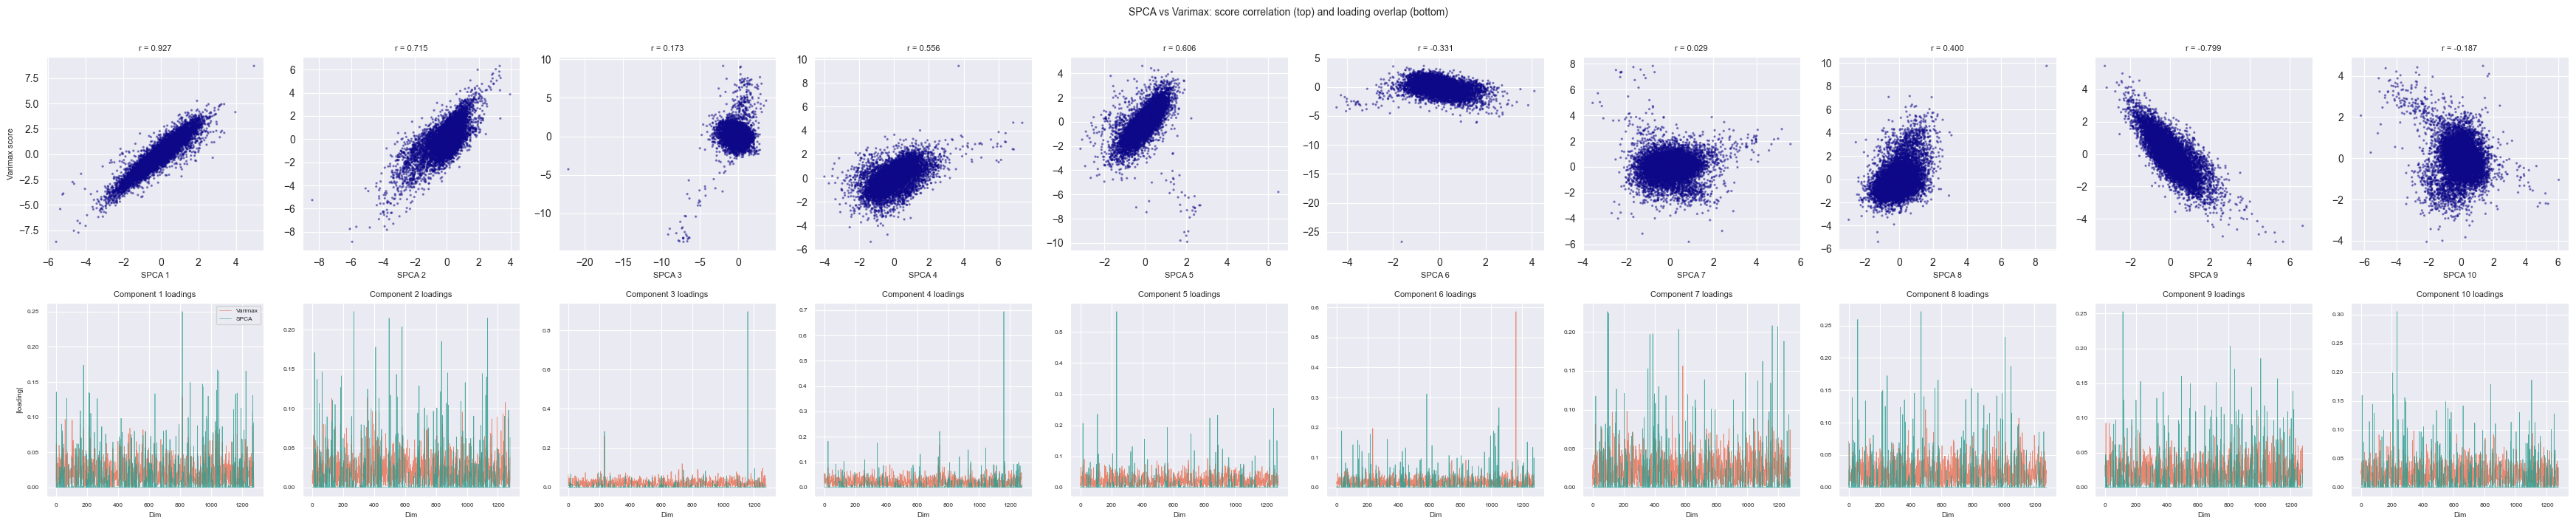

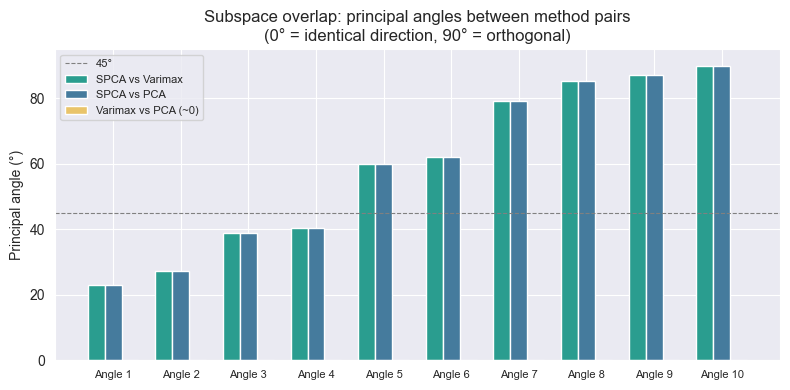


Summary:
  R²: PCA=75.7%  Varimax=75.7%  SPCA=43.9%
  Mean stability: Varimax=0.979  SPCA=0.599
  Mean |cos sim| SPCA vs Varimax: 0.472


In [100]:
from matplotlib.gridspec import GridSpec

comp_labels_v = [f"C{i+1}" for i in range(N_COMPONENTS)]

# ── Fig 1: Loading heatmaps — SPCA | Varimax | PCA (side-by-side) ─────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 8), sharex=False)
for ax, comps, title in [
    (axes[0], spca_comps_s,
     f"Sparse PCA  (α={ALPHA}, {sparsity_s.mean():.0f}% exact zeros)"),
    (axes[1], var_comps,
     f"PCA + Varimax  (0 exact zeros, loading kurtosis={float(np.mean((var_comps**4).mean(axis=1) / (var_comps**2).mean(axis=1)**2)):.1f})"),
    (axes[2], pca_comps_s,
     f"PCA  ({ev_ratio.sum()*100:.1f}% var explained)"),
]:
    vmax = np.abs(comps).max()
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(comps, aspect="auto", cmap="RdBu_r", norm=norm, interpolation="nearest")
    ax.set_yticks(range(N_COMPONENTS))
    ax.set_yticklabels(comp_labels_v, fontsize=8)
    ax.set_xlabel("Embedding dimension (0-1279)")
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, label="Loading", shrink=0.8, pad=0.01)
plt.suptitle(f"Loading matrices: SPCA vs Varimax vs PCA  —  {SPCA_DATASET}", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "vmx_loading_heatmaps.png"), dpi=150)
plt.show()

# ── Fig 2: Loading magnitude distributions ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
bins = np.linspace(0, max(np.abs(pca_comps_s).max(), np.abs(var_comps).max(),
                          np.abs(spca_comps_s).max()) * 1.05, 80)
for ax, comps, label, color in [
    (axes[0], spca_comps_s, f"SPCA (α={ALPHA})", "#2a9d8f"),
    (axes[1], var_comps,    "Varimax",            "#e76f51"),
    (axes[2], pca_comps_s,  "PCA",                "#457b9d"),
]:
    vals = np.abs(comps).ravel()
    ax.hist(vals, bins=bins, color=color, edgecolor="white", linewidth=0.3, log=True)
    kurt = float(np.mean(comps.ravel()**4) / np.mean(comps.ravel()**2)**2)
    ax.axvline(np.median(vals), color="black", linestyle="--", linewidth=0.8,
               label=f"median={np.median(vals):.4f}")
    ax.set_title(f"{label}\nkurtosis={kurt:.1f}", fontsize=10)
    ax.set_xlabel("|loading|")
    ax.set_ylabel("Count (log)")
    ax.legend(fontsize=8)
plt.suptitle("Distribution of |loading| values  (higher kurtosis = more concentrated)", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "vmx_loading_distributions.png"), dpi=150)
plt.show()

# ── Fig 3: Bootstrap stability comparison ─────────────────────────────────────
sort_v = np.argsort(mean_stab_var)[::-1]
x = np.arange(N_COMPONENTS)
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, mean_stab_var[sort_v], w, yerr=std_stab_var[sort_v],
       color="#e76f51", capsize=4, label="Varimax", edgecolor="white")
ax.bar(x + w/2, mean_stab[sort_v],     w, yerr=std_stab[sort_v],
       color="#2a9d8f", capsize=4, label=f"SPCA (α={ALPHA})", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([f"C{sort_v[i]+1}" for i in range(N_COMPONENTS)], fontsize=9)
ax.axhline(0.9, color="green",  linestyle="--", linewidth=0.8, label="0.9 stable")
ax.axhline(0.7, color="orange", linestyle="--", linewidth=0.8, label="0.7 marginal")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Mean bootstrap |cos sim|")
ax.set_title(f"Bootstrap stability: Varimax vs SPCA  (N={N_BOOTSTRAP}, frac={BOOT_FRAC})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "vmx_bootstrap_stability.png"), dpi=150)
plt.show()

# ── Fig 4: Score scatter + pairwise correlations ──────────────────────────────
fig, axes = plt.subplots(2, N_COMPONENTS, figsize=(3.5 * N_COMPONENTS, 7), squeeze=False)
for k in range(N_COMPONENTS):
    # Top row: SPCA scores vs Varimax scores for this component
    r_sv = np.corrcoef(sc_spca[:, k], sc_varimax[:, k])[0, 1]
    axes[0, k].scatter(sc_spca[:, k], sc_varimax[:, k],
                       c=freq_s, cmap="plasma", s=2, alpha=0.4, rasterized=True)
    axes[0, k].set_xlabel(f"SPCA {k+1}", fontsize=8)
    axes[0, k].set_ylabel(f"Varimax {k+1}", fontsize=8) if k == 0 else None
    axes[0, k].set_title(f"r = {r_sv:.3f}", fontsize=8)

    # Bottom row: loading comparison stem overlay
    ax = axes[1, k]
    dims = np.arange(spca_comps_s.shape[1])
    ax.plot(dims, np.abs(var_comps[k]),   color="#e76f51", linewidth=0.5, alpha=0.8, label="Varimax")
    ax.plot(dims, np.abs(spca_comps_s[k]),color="#2a9d8f", linewidth=0.5, alpha=0.8, label="SPCA")
    ax.set_xlabel("Dim", fontsize=7)
    ax.set_ylabel("|loading|", fontsize=7) if k == 0 else None
    ax.set_title(f"Component {k+1} loadings", fontsize=8)
    ax.tick_params(labelsize=6)
    if k == 0:
        ax.legend(fontsize=6)

axes[0, 0].set_ylabel("Varimax score", fontsize=8)
fig.suptitle(f"SPCA vs Varimax: score correlation (top) and loading overlap (bottom)",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "vmx_score_and_loading_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── Fig 5: Principal angles bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(N_COMPONENTS)
ax.bar(x - 0.25, angles_sv, 0.25, color="#2a9d8f", label="SPCA vs Varimax")
ax.bar(x,        angles_sp, 0.25, color="#457b9d", label="SPCA vs PCA")
ax.bar(x + 0.25, angles_vp, 0.25, color="#e9c46a", label="Varimax vs PCA (~0)")
ax.set_xticks(x)
ax.set_xticklabels([f"Angle {i+1}" for i in range(N_COMPONENTS)], fontsize=8)
ax.set_ylabel("Principal angle (°)")
ax.set_title("Subspace overlap: principal angles between method pairs\n"
             "(0° = identical direction, 90° = orthogonal)")
ax.axhline(45, color="grey", linestyle="--", linewidth=0.8, label="45°")
ax.legend(fontsize=8)
ax.set_ylim(0, 95)
plt.tight_layout()
plt.savefig(os.path.join(SPCA_OUTPUT_DIR, "vmx_principal_angles.png"), dpi=150)
plt.show()

print(f"\nSummary:")
print(f"  R²: PCA={ev_ratio.sum()*100:.1f}%  Varimax={r2_var*100:.1f}%  SPCA={r2_spca_c*100:.1f}%")
print(f"  Mean stability: Varimax={mean_stab_var.mean():.3f}  SPCA={mean_stab.mean():.3f}")
print(f"  Mean |cos sim| SPCA vs Varimax: {np.abs(np.corrcoef(sc_spca.T, sc_varimax.T)[:N_COMPONENTS, N_COMPONENTS:].diagonal()).mean():.3f}")

# DYLAN'S SAE ANALYSIS PLAN

Train my own Sparse autoencoder and compare performance to InterPLM's pretrained SAE on Layer 24, 30, and 33 embeddings

---
## Sparse Autoencoder — Hyperparameter Playground

Train a minimal SAE on `layer_24_emb_array` and immediately see reconstruction quality.
Tune the four knobs at the top of the next cell:

| Parameter | What it does | Start here |
|---|---|---|
| `DICT_SIZE` | Hidden layer width (> input = overcomplete) | `4 * 1280 = 5120` |
| `L1_COEFF` | Sparsity penalty — higher → fewer active features | `1e-3` |
| `LR` | Adam learning rate | `1e-4` |
| `N_EPOCHS` | Training passes over the data | `20` |

Train: 10,709  |  Test: 2,677


training:   0%|          | 0/20 [00:00<?, ?it/s]

Test R²      : -30.81%
Mean L0      : 1521.8 / 5120 (29.7%)
Dead features: 70.0%


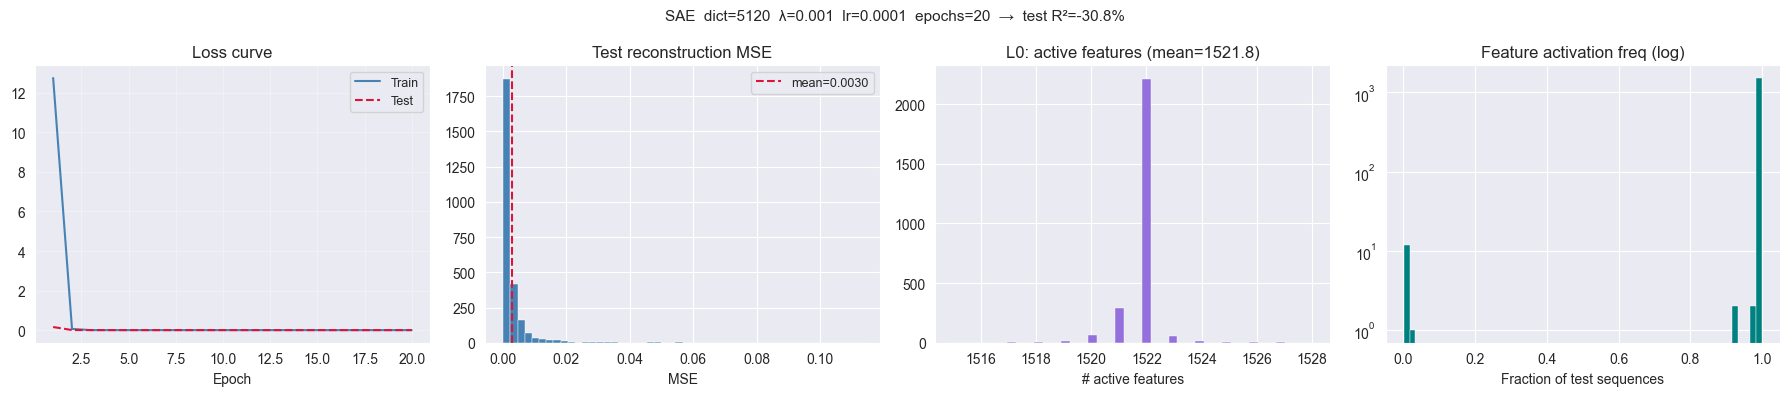

In [105]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Tune these ────────────────────────────────────────────────────────────────
DICT_SIZE  = 4 * layer_24_emb_array.shape[1]   # hidden layer width
L1_COEFF   = 1e-3                               # sparsity weight
LR         = 1e-4                               # learning rate
N_EPOCHS   = 20                                 # training epochs
BATCH_SIZE = 256
TEST_FRAC  = 0.2                                # fraction held out for test
# ─────────────────────────────────────────────────────────────────────────────

# ── Train / test split ────────────────────────────────────────────────────────
rng_split = np.random.default_rng(0)
idx       = rng_split.permutation(len(layer_24_emb_array))
n_test    = int(len(idx) * TEST_FRAC)
tr_idx, te_idx = idx[n_test:], idx[:n_test]

X_tr = torch.tensor(layer_24_emb_array[tr_idx], dtype=torch.float32)
X_te = torch.tensor(layer_24_emb_array[te_idx], dtype=torch.float32)
print(f"Train: {len(X_tr):,}  |  Test: {len(X_te):,}")

loader = DataLoader(TensorDataset(X_tr), batch_size=BATCH_SIZE, shuffle=True)

class SAE(nn.Module):
    def __init__(self, d_in, d_hidden):
        super().__init__()
        self.b_pre = nn.Parameter(torch.zeros(d_in))
        self.enc   = nn.Linear(d_in, d_hidden)
        self.dec   = nn.Linear(d_hidden, d_in, bias=False)
        nn.init.zeros_(self.enc.bias)
        w = self.dec.weight.data
        self.dec.weight.data = w / w.norm(dim=0, keepdim=True)

    def forward(self, x):
        f = torch.relu(self.enc(x - self.b_pre))
        return self.dec(f) + self.b_pre, f

    @torch.no_grad()
    def renorm_dec(self):
        w = self.dec.weight
        self.dec.weight.copy_(w / w.norm(dim=0, keepdim=True).clamp(min=1e-8))

model = SAE(layer_24_emb_array.shape[1], DICT_SIZE).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=LR)

train_losses, test_losses = [], []
X_te_d = X_te.to(device)

for epoch in tqdm(range(N_EPOCHS), desc="training"):
    model.train()
    ep_loss = 0.0
    for (xb,) in loader:
        xb = xb.to(device)
        x_hat, f = model(xb)
        loss = ((xb - x_hat)**2).mean() + L1_COEFF * f.mean()
        opt.zero_grad(); loss.backward(); opt.step(); model.renorm_dec()
        ep_loss += loss.item()
    train_losses.append(ep_loss / len(loader))

    model.eval()
    with torch.no_grad():
        x_hat_te, f_te = model(X_te_d)
        te_loss = ((X_te_d - x_hat_te)**2).mean().item() + L1_COEFF * f_te.mean().item()
    test_losses.append(te_loss)

# ── Evaluate ──────────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    x_hat_te, f_te = model(X_te_d)

orig_te   = X_te.numpy()
x_hat_np  = x_hat_te.cpu().numpy()
f_np      = f_te.cpu().numpy()

def r2(orig, recon):
    return 1 - ((orig - recon)**2).sum() / ((orig - orig.mean(axis=0))**2).sum()

l0   = (f_np > 0).sum(axis=1).mean()
dead = ((f_np > 0).sum(axis=0) == 0).mean() * 100
print(f"Test R²      : {r2(orig_te, x_hat_np)*100:.2f}%")
print(f"Mean L0      : {l0:.1f} / {DICT_SIZE} ({l0/DICT_SIZE*100:.1f}%)")
print(f"Dead features: {dead:.1f}%")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Loss curves
epochs_x = np.arange(1, N_EPOCHS + 1)
axes[0].plot(epochs_x, train_losses, label="Train", color="steelblue")
axes[0].plot(epochs_x, test_losses,  label="Test",  color="crimson", linestyle="--")
axes[0].set_title("Loss curve"); axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Test MSE distribution
mse_te = ((orig_te - x_hat_np)**2).mean(axis=1)
axes[1].hist(mse_te, bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
axes[1].axvline(mse_te.mean(), color="crimson", linestyle="--",
                label=f"mean={mse_te.mean():.4f}")
axes[1].set_title("Test reconstruction MSE"); axes[1].set_xlabel("MSE")
axes[1].legend(fontsize=9)

# L0 distribution
axes[2].hist((f_np > 0).sum(axis=1), bins=40, color="mediumpurple",
             edgecolor="white", linewidth=0.3)
axes[2].set_title(f"L0: active features (mean={l0:.1f})")
axes[2].set_xlabel("# active features")

# Feature activation frequency
feat_freq = (f_np > 0).mean(axis=0)
axes[3].hist(feat_freq[feat_freq > 0], bins=60, color="teal",
             edgecolor="white", linewidth=0.3, log=True)
axes[3].set_title("Feature activation freq (log)")
axes[3].set_xlabel("Fraction of test sequences")

plt.suptitle(f"SAE  dict={DICT_SIZE}  λ={L1_COEFF}  lr={LR}  epochs={N_EPOCHS}"
             f"  →  test R²={r2(orig_te, x_hat_np)*100:.1f}%", fontsize=11)
plt.tight_layout()
plt.show()

In [107]:
# test putting an embedding through the encoder and decoder
test_emb = torch.tensor(layer_24_emb_array[0:1], dtype=torch.float32).to(device)
with torch.no_grad():
    recon, feat = model(test_emb)
print(f"Original embedding:\n{test_emb.cpu().numpy()}")
print(f"\nReconstructed embedding:\n{recon.cpu().numpy()}")
print(f"\nActive features in code:\n{(feat > 0).cpu().numpy()}")
# cosine similarity between original and reconstructed
cos_sim = torch.nn.functional.cosine_similarity(test_emb, recon).item()
print(f"\nCosine similarity between original and reconstructed: {cos_sim:.4f}")

Original embedding:
[[-1.3383694 -1.9689432  2.1573026 ... -1.2659724 -0.7177042  1.5727092]]

Reconstructed embedding:
[[-1.3607681  -2.130549    2.2100632  ... -1.3672775  -0.73415697
   1.6029112 ]]

Active features in code:
[[ True False False ...  True False False]]

Cosine similarity between original and reconstructed: 0.9999
